# 02 — LDA em Tweets BR Eleições 2022 (PT-BR)

## O que esse notebook faz

Aplica **Latent Dirichlet Allocation (LDA)** ao corpus de tweets das eleições brasileiras 2022.
Segue a mesma estrutura de pipeline do `02_lda_folha.ipynb`, com adaptações para texto curto/informal.

**Corpus:** Tweets BR 2022 — ~200k tweets PT-BR, texto curto (~23 tokens), discurso político.

**Hipótese H2:** LDA em texto curto/informal tende a degradar vs corpus formal —
este notebook documenta empiricamente esse comportamento.


## 1. Setup e imports

Carregamos parâmetros do `configs/params.yaml` (entrada `corpora.tweets_bre2022`), o seed global e as funções dos pipelines reusáveis:

- `_helpers.lemmatize_corpus(docs, lang, params)` → tokens lematizados + Dictionary com filter_extremes
- `_helpers.grid_search_k / train_lda / extract_topics_keywords / compute_doc_distributions` → fit e extração
- `_helpers.name_all_topics` → rotulagem via Ollama (modelo em `params.yaml`)
- `_helpers.*` → métricas (c_v, exclusivity, FREX, NPMI, etc.)

In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
# Cell 1 — Imports
import sys, os, json, time, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from gensim.models import LdaMulticore

from _helpers import load_params, get_corpus_config, get_seed, load_corpus
from _helpers import lemmatize_corpus
from _helpers import (
    grid_search_k, grid_search_alpha_eta, train_lda, extract_topics_keywords,
    compute_doc_distributions, qualitative_report,
)
from _helpers import name_all_topics
from _helpers import compute_coherence_npmi, compute_metrics_table, diagnose_cv_window
from _helpers import (
    compute_coherence_cv, compute_exclusivity_ctfidf, compute_diversity,
    compute_topic_diversity, compute_frex_score, compute_stability, export_results, export_topics_for_eval,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — Carrega params do params.yaml
CORPUS_ID = "tweets_bre2022"
LANG = "pt"

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
TEXT_COL = cfg["text_column"]

print(f"corpus_id = {CORPUS_ID}")
print(f"text_column = {TEXT_COL}")
print(f"language = {LANG}")
print(f"seed = {seed}")
print(f"covariates (usadas no STM, não no LDA) = {cfg.get('covariates', [])}")

corpus_id = tweets_bre2022
text_column = message
language = pt
seed = 42
covariates (usadas no STM, não no LDA) = ['category']


## 2. Corpus Tweets BR Eleições 2022

### Origem e schema

- Dataset de tweets em PT-BR sobre as eleições brasileiras de 2022 (Zenodo 14834749)
- Filtros aplicados: `len(message.split()) >= 20` é relaxado aqui — texto curto é a própria característica do corpus (~23 tokens/doc em média)
- Schema padronizado: `post_id, message, date, category, lang`

### Limitações

- **`category` não é categoria temática**: por construção do corpus, este campo é um proxy temporal (`YYYY-MM`, mês de coleta), não um rótulo de assunto. Ver `covariates: [category]` em `params.yaml` — usado no STM como controle temporal, não como ground-truth de tópico.
- **Texto curto/informal (H2)**: tweets têm vocabulário muito mais esparso que corpus formal (Folha), o que tende a degradar a coerência c_v do LDA — esse notebook documenta empiricamente esse efeito.

In [3]:
# Cell 3 — Carrega corpus_limpo.csv (latest-wins: le diretamente do output do 01-preprocessing)
from _helpers import resolve_latest_dir

_corpus_base = Path(f"../../01-preprocessing/data/output/{CORPUS_ID}")
_corpus_dir  = resolve_latest_dir(
    _corpus_base,
    contains="corpus_limpo.csv",
    fallback_dir=Path(f"../data/input/{CORPUS_ID}"),
)
print(f"Versao do corpus: {_corpus_dir.name}")

df = load_corpus(str(_corpus_dir) + "/")
docs     = df[TEXT_COL].astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()

print(f"Total docs: {len(docs):,}")
print(f"Colunas: {list(df.columns)}")
df.head(3)

  versão resolvida: tweets_bre2022_20260629_215159/ (latest)
Versao do corpus: tweets_bre2022_20260629_215159
Carregado: corpus_limpo.csv (8811 docs, SEM coluna 'sentiment' — rode 03-sentiment antes para ter cruzamento topic x sentiment automatico)
Total docs: 8,811
Colunas: ['tweet_id', 'message', 'message_raw', 'post_id', 'data', 'user', 'user_info', 'has_mention', 'mentions', 'is_reply', 'reply_to', 'is_quote', 'quoted_from', 'is_retweet', 'retweeted_from', 'hashtags', 'native_mentions', 'retweet_mentions', 'Unnamed: 0', 'platform', 'election', 'category']


,tweet_id,message,message_raw,post_id,data,user,user_info,has_mention,mentions,is_reply,...,quoted_from,is_retweet,retweeted_from,hashtags,native_mentions,retweet_mentions,Unnamed: 0,platform,election,category
0,1562979518280699904,"@LulaOficial “Lulinha”, “Alckmin”, “Paulo Frei...","@LulaOficial “Lulinha”, “Alckmin”, “Paulo Frei...",tw_00044339,2022-08-26 01:45:30,luciana_onofre,"{'id': 2853238599, 'name': 'Luciana Lula da Si...",True,"[{'id': '2670726740', 'username': 'LulaOficial'}]",False,...,NaN,True,"{'user': 'UOLNoticias', 'user_id': 14594698, '...","['#LADRAONOJN', '#LulaNoJN']",NaN,NaN,NaN,twitter,br_2022,2022-08
1,1562053466830389249,@jairbolsonaro @Anitta Bora da aquela pesquisa...,@jairbolsonaro @Anitta Bora da aquela pesquisa...,tw_00073680,2022-08-23 12:25:42,mafra_leoni,"{'id': 1479929106804482048, 'name': 'Leoni Gar...",True,"[{'id': '128372940', 'username': 'jairbolsonar...",False,...,NaN,True,"{'user': 'Jouberth19', 'user_id': 350476403, '...",['#GloboLixo'],NaN,NaN,NaN,twitter,br_2022,2022-08
2,1561862082315837440,Hoje eu tô muito Bonnerzete e Renatete! #Jorna...,Hoje eu tô muito Bonnerzete e Renatete! #Jorn...,tw_00102132,2022-08-22 23:45:13,vieradriano,"{'id': 1349339460027211777, 'name': 'Adrianno ...",False,NaN,False,...,NaN,True,"{'user': 'tvlizando', 'user_id': 2471757957, '...","['#JornalNacional', '#JN', '#ForaBolsonaro']",NaN,NaN,NaN,twitter,br_2022,2022-08


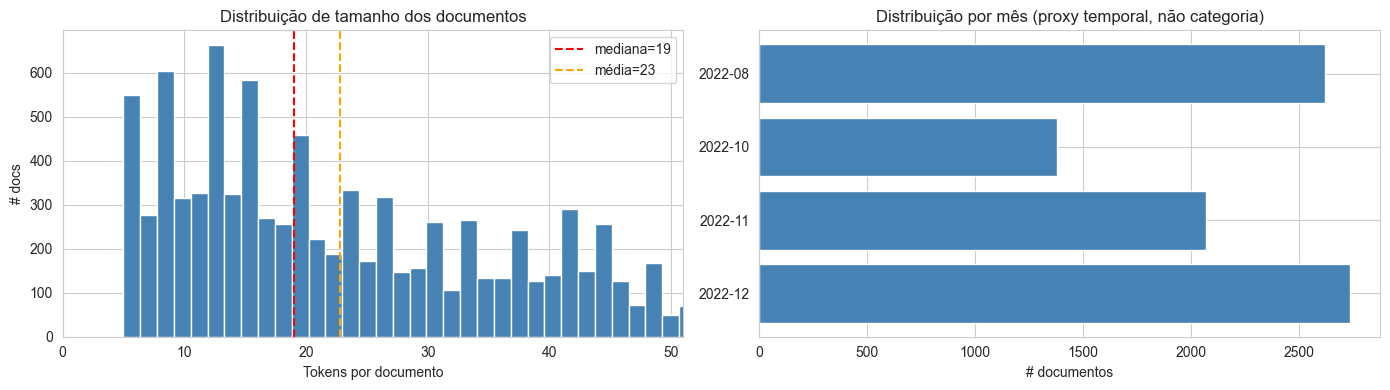


Descritivas n_tokens: {'count': 8811.0, 'mean': 22.75939166950403, 'std': 13.05769920589274, 'min': 5.0, '25%': 12.0, '50%': 19.0, '75%': 33.0, 'max': 88.0}


In [4]:
# Cell 4 — Estatisticas descritivas + distribuicao de tokens
df["n_tokens"] = df["message"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["n_tokens"], bins=60, edgecolor="white", color="steelblue")
axes[0].axvline(df["n_tokens"].median(), color="red", linestyle="--", label=f'mediana={df["n_tokens"].median():.0f}')
axes[0].axvline(df["n_tokens"].mean(), color="orange", linestyle="--", label=f'média={df["n_tokens"].mean():.0f}')
axes[0].set_xlabel("Tokens por documento"); axes[0].set_ylabel("# docs")
axes[0].set_title("Distribuição de tamanho dos documentos"); axes[0].legend()
axes[0].set_xlim(0, df["n_tokens"].quantile(0.99))

cat_counts = df["category"].value_counts().sort_index()
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="steelblue")
axes[1].set_xlabel("# documentos"); axes[1].set_title("Distribuição por mês (proxy temporal, não categoria)")
plt.tight_layout(); plt.show()

print(f"\nDescritivas n_tokens: {df['n_tokens'].describe().to_dict()}")

## 3. Lematização e construção do vocabulário

### O que `_helpers.lemmatize_corpus` faz

1. Carrega spaCy `pt_core_news_lg` (cached em module-level)
2. Para cada doc: tokeniza, descarta stopwords (lista interna spaCy) + tokens não-alfa + tokens curtos (`len(lemma) <= 2`)
3. Constrói gensim `Dictionary` com `filter_extremes(no_below=5, no_above=0.5)`:
   - Remove palavras que aparecem em <5 docs (raras, ruído)
   - Remove palavras em >50% dos docs (genéricas, sem poder discriminante — ex.: "disse")

### Por que lematizar (vs stemming)

- Lematização preserva forma legível (`correndo` → `correr`; stemming agressivo produziria `corr`)
- Mais interpretável para a banca da dissertação
- Custo: ~30s a ~3min em CPU dependendo do volume

In [5]:
# Cell 5 — Lematiza corpus
print("Lematizando (single-process spaCy pt_core_news_lg)...")
t0 = time.time()
tokenized, dictionary = lemmatize_corpus(docs, LANG, params)
print(f"  done em {time.time()-t0:.0f}s")
print(f"  vocab final: {len(dictionary):,} palavras (após filter_extremes)")

# Estatísticas dos tokens lemmatizados
n_tokens_lemma = [len(t) for t in tokenized]
n_unique = [len(set(t)) for t in tokenized]

print(f"\n  avg tokens/doc após lemmatize: {np.mean(n_tokens_lemma):.1f}")
print(f"  avg unique tokens/doc: {np.mean(n_unique):.1f}")

Lematizando (single-process spaCy pt_core_news_lg)...


  done em 22s
  vocab final: 2,617 palavras (após filter_extremes)

  avg tokens/doc após lemmatize: 10.9
  avg unique tokens/doc: 10.4


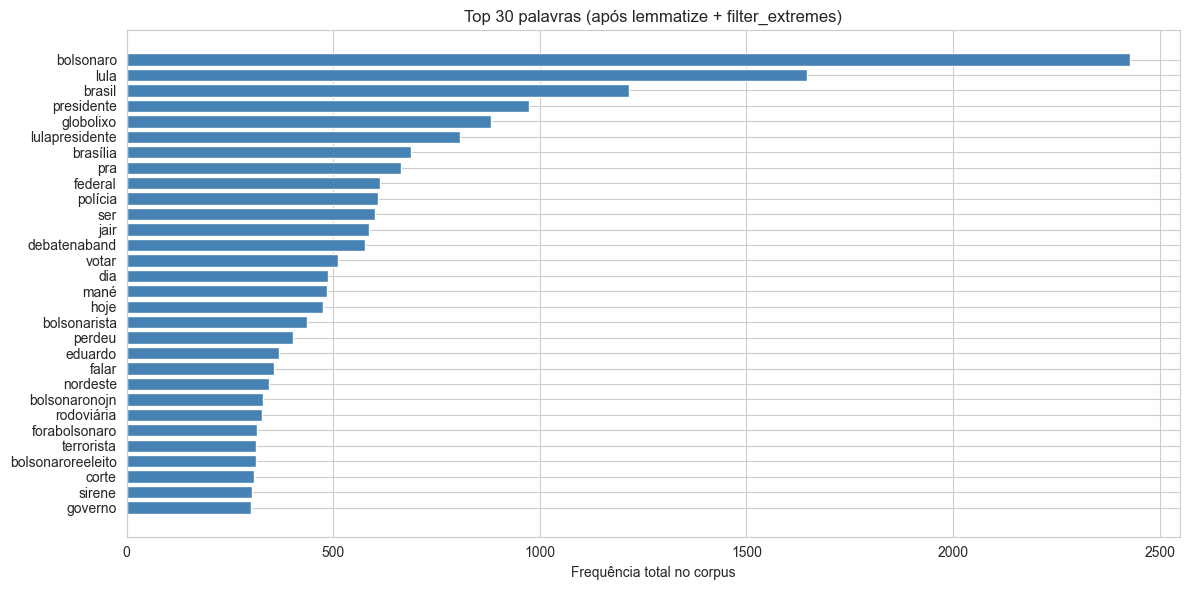

In [6]:
# Cell 6 — Top 30 palavras mais frequentes no vocabulário final
all_tokens = [t for doc in tokenized for t in doc]
freq = Counter(all_tokens)
top30 = freq.most_common(30)

fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*top30)
ax.barh(words[::-1], counts[::-1], color="steelblue")
ax.set_xlabel("Frequência total no corpus")
ax.set_title("Top 30 palavras (após lemmatize + filter_extremes)")
plt.tight_layout(); plt.show()

In [7]:
# Cell 7 — Bag-of-Words representation
corpus_bow = [dictionary.doc2bow(d) for d in tokenized]
print(f"corpus_bow: {len(corpus_bow):,} docs")
print(f"avg unique tokens/doc no BoW: {np.mean([len(b) for b in corpus_bow]):.1f}")
print(f"\nExemplo doc[0] BoW (primeiros 10 pares (word_id, count)):")
for word_id, count in corpus_bow[0][:10]:
    print(f"  {dictionary[word_id]:20s}  count={count}")

corpus_bow: 8,811 docs
avg unique tokens/doc no BoW: 8.8

Exemplo doc[0] BoW (primeiros 10 pares (word_id, count)):
  alckmin               count=1
  bobo                  count=1
  comentar              count=1
  corte                 count=1
  durante               count=1
  entrevista            count=1
  freire                count=1
  ladraonojn            count=1
  lulanojn              count=1
  lulinha               count=1


## 4. Seleção de K (número de tópicos)

### Por que K importa

K é o **único hiperparâmetro estrutural** do LDA. Influencia a granularidade dos tópicos:
- K muito baixo → tópicos macro/genéricos (varios temas misturados em um)
- K muito alto → fragmentação (mesmo tema dividido em múltiplos clusters)

### Como escolher

Padrão na literatura: rodar LDA em vários K, calcular **c_v coherence** (Roder et al. 2015) — métrica que combina:
- co-ocorrência das top-N palavras numa janela deslizante
- score NPMI normalizado
- agregação via cosine similarity

Limitação conhecida: **c_v penaliza K alto** (Stevens et al. 2012). Por isso complementamos com inspeção qualitativa em múltiplos K (próxima célula).

In [8]:
# Cell 8 — Grid search K (carrega resultado do run standalone se existir)
from _helpers import make_run_output_dir
# Subpasta lda/ separa runs por modelo (espelha folha migrado)
BASE_OUTPUT_DIR = Path(f"../data/output/{CORPUS_ID}/lda")
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Saida carimbada por execucao: <corpus>_<data>_<hora> (nao sobrescreve runs anteriores)
OUTPUT_DIR = make_run_output_dir(BASE_OUTPUT_DIR, CORPUS_ID)
out_dir = str(OUTPUT_DIR)
# Cache do grid search: vive no diretorio-BASE lda/ (reutilizado entre runs)
m_path = f"{BASE_OUTPUT_DIR}/lda_metrics.csv"

# --- ADICAO 2026-08-16 (protocolo): o cache de grid e PEGAJOSO — roda uma vez e
#     sobrevive a toda mudanca de codigo posterior (mapeamento secao 2.11.A). Sob o
#     protocolo novo o eixo de ordenacao passou a ser o NPMI, entao um cache SEM a
#     curva de NPMI esta desatualizado por definicao e precisa ser recomputado.
#     Esta e a invalidacao declarada que a P14 pedia: nao se apaga arquivo na mao.
#     ADICAO 2026-08-23: a curva de Diversity (segundo eixo, secao 1.5) tambem
#     invalida o cache — mesma correcao ja aplicada em 02_lda_folha.ipynb (Cell 8).
_cache_tem_npmi = False
_cache_tem_diversity = False
if os.path.exists(m_path):
    _m_chk = pd.read_csv(m_path)
    _cache_tem_npmi = ("k_npmi_scores" in _m_chk.columns
                       and pd.notna(_m_chk.iloc[0].get("k_npmi_scores")))
    _cache_tem_diversity = ("k_diversity_scores" in _m_chk.columns
                       and pd.notna(_m_chk.iloc[0].get("k_diversity_scores")))
    if not (_cache_tem_npmi and _cache_tem_diversity):
        print("Cache do grid sem k_npmi_scores/k_diversity_scores (pre-protocolo 2026-08-22) — recomputando.")

if os.path.exists(m_path) and _cache_tem_npmi and _cache_tem_diversity:
    m = pd.read_csv(m_path)
    scores = ast.literal_eval(m.iloc[0]["k_grid_scores"])
    scores = {int(k): float(v) for k, v in scores.items()}
    npmi_scores = {int(k): float(v) for k, v in
                   ast.literal_eval(str(m.iloc[0]["k_npmi_scores"])).items()}
    div_scores = {int(k): float(v) for k, v in
                   ast.literal_eval(str(m.iloc[0]["k_diversity_scores"])).items()}
    _pkey = "k_perplexity_scores"
    if _pkey in m.columns and pd.notna(m.iloc[0].get(_pkey)):
        perplexity_scores = ast.literal_eval(str(m.iloc[0][_pkey]))
        perplexity_scores = {int(k): float(v) for k, v in perplexity_scores.items()}
    else:
        perplexity_scores = {}
    print(f"Carregado grid pre-computado de {m_path}")
    print(f"  K range: {sorted(scores.keys())}")
    print(f"  passes: {m.iloc[0].get('grid_passes', '?')}")
else:
    K_RANGE = [3, 5, 7, 8, 10, 12, 15, 20, 25, 30]
    print(f"Rodando grid K em {K_RANGE} passes=20 (~13min)...")
    scores, perplexity_scores, npmi_scores, div_scores = grid_search_k(
        corpus_bow, dictionary, tokenized, K_RANGE, seed=seed, passes=20,
        return_npmi=True,
        return_diversity=True,
        checkpoint_path=BASE_OUTPUT_DIR / "lda_k_checkpoint.csv")
    print(f"Done.")

scores

Cache do grid sem k_npmi_scores/k_diversity_scores (pre-protocolo 2026-08-22) — recomputando.
Rodando grid K em [3, 5, 7, 8, 10, 12, 15, 20, 25, 30] passes=20 (~13min)...


Done.


{3: 0.35365183441278386,
 5: 0.3953932244169229,
 7: 0.36406854890138396,
 8: 0.3996524793702455,
 10: 0.3882596002820249,
 12: 0.445706925828354,
 15: 0.5095245496535776,
 20: 0.5222542691552661,
 25: 0.4931880544654545,
 30: 0.4796325459188132}

Salvo: ..\data\output\tweets_bre2022\lda\lda_grid_k_cv.png


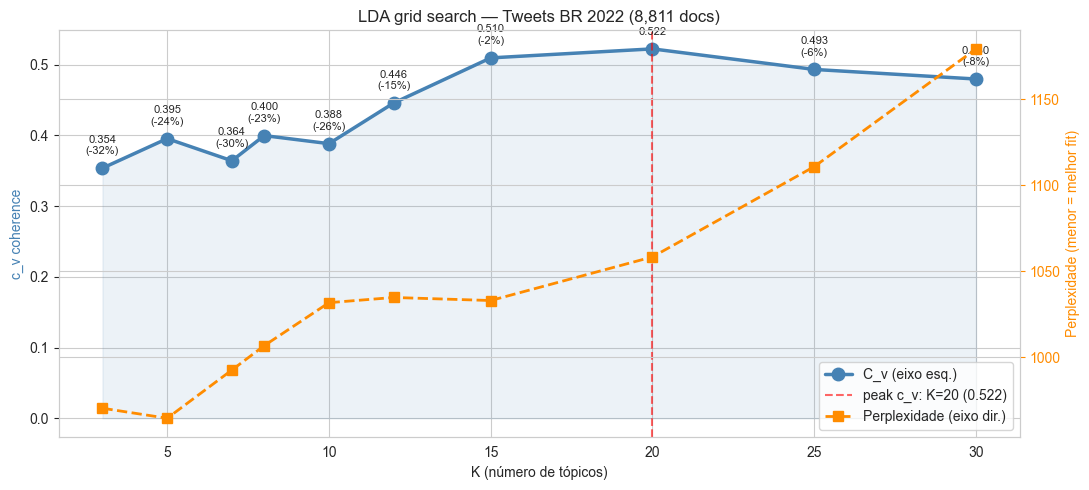


Peak: K=20 (c_v=0.5223)
K=10: c_v=0.3883 (delta vs peak: -25.7%)


In [9]:
# Cell 9 — Visualizacao c_v vs K
fig, ax = plt.subplots(figsize=(11, 5))
ks = sorted(scores)
vs = [scores[k] for k in ks]

ax.plot(ks, vs, marker="o", linewidth=2.5, markersize=9, color="steelblue", label="C_v (eixo esq.)")
ax.fill_between(ks, vs, alpha=0.1, color="steelblue")

peak_k = max(scores, key=scores.get)
ax.axvline(peak_k, color="red", linestyle="--", alpha=0.6, label=f"peak c_v: K={peak_k} ({scores[peak_k]:.3f})")

# Annotate each K
for k, v in zip(ks, vs):
    delta = (v - scores[peak_k]) / scores[peak_k] * 100
    label = f"{v:.3f}" if k == peak_k else f"{v:.3f}\n({delta:+.0f}%)"
    ax.annotate(label, (k, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8)

ax.set_xlabel("K (número de tópicos)"); ax.set_ylabel("c_v coherence", color="steelblue")
ax.set_title(f"LDA grid search — Tweets BR 2022 ({len(docs):,} docs)")
if perplexity_scores:
    ax2 = ax.twinx()
    pks = sorted(perplexity_scores)
    pvs = [perplexity_scores[k] for k in pks]
    ax2.plot(pks, pvs, marker="s", linewidth=2, markersize=7, color="darkorange",
             linestyle="--", label="Perplexidade (eixo dir.)")
    ax2.set_ylabel("Perplexidade (menor = melhor fit)", color="darkorange")
    ax2.tick_params(axis="y", colors="darkorange")
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines1, labels1 = ax.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
else:
    ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(BASE_OUTPUT_DIR / "lda_grid_k_cv.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {BASE_OUTPUT_DIR / 'lda_grid_k_cv.png'}")
plt.show()

print(f"\nPeak: K={peak_k} (c_v={scores[peak_k]:.4f})")
if 10 in scores:
    print(f"K=10: c_v={scores[10]:.4f} (delta vs peak: {(scores[10]-scores[peak_k])/scores[peak_k]*100:+.1f}%)")

## 5. Inspeção qualitativa multi-K

Como `c_v` favorece K menor, precisamos olhar **os tópicos em si** para escolher K com critério metodológico (não só estatístico). Carregamos os tópicos de K=5, 7, 10, 15, 30 pré-computados em `lda_multi_k_inspect.csv`, se disponível (execução prévia opcional — ver célula abaixo).

In [10]:
# Cell 10 — Multi-K topics side by side (opcional, requer lda_multi_k_inspect.csv pre-computado)
multi_path = f"{out_dir}/lda_multi_k_inspect.csv"
if os.path.exists(multi_path):
    multi = pd.read_csv(multi_path)
    for k_val in sorted(multi["k"].unique()):
        sub = multi[multi["k"] == k_val].sort_values("topic_id")
        print(f"=== K={k_val} ===")
        for _, row in sub.iterrows():
            kws = row["keywords"].split(", ")[:8]
            print(f"  T{int(row['topic_id']):2d}: {', '.join(kws)}")
        print()
else:
    print("lda_multi_k_inspect.csv nao encontrado — pulando inspecao multi-K (opcional).")

lda_multi_k_inspect.csv nao encontrado — pulando inspecao multi-K (opcional).


In [11]:
# Cell 11 — Distribuição mensal por K (analise visual)
# category = mes de coleta (proxy temporal eleitoral), nao categoria tematica.
# Aqui validamos cobertura temporal (todos os meses representados), nao cobertura de assunto.
month_dist = df['category'].value_counts().sort_index()
print('Distribuicao de docs por mes (proxy temporal, params.yaml: covariates=[category]):')
print(month_dist.to_string())

Distribuicao de docs por mes (proxy temporal, params.yaml: covariates=[category]):
category
2022-08    2621
2022-10    1381
2022-11    2070
2022-12    2739


## 6. Decisão de K e treino final

**Trade-off:** `c_v` favorece K pequeno. Combine com inspeção qualitativa (seção 5) — esperado:
coerência mais baixa que corpus formal (H2), dado o vocabulário esparso de texto curto.
Ajuste `BEST_K` na célula abaixo se necessário.

Faixa de K declarada para tweets_bre2022: [10,25] (5 de 10 pontos admissiveis)
BEST_K pelo protocolo (secao 1.5): 10  (NPMI -0.0046)
  criterio: pareto NPMI x Diversity, desempate menor K
  NOTA: por C_v o argmax na faixa seria K=20 (C_v 0.5223 vs 0.3883 em K=10).
  Divergencia entre eixos e informacao a reportar, nao erro. O NPMI decide.

  K      NPMI       C_v   Perplex.   admissivel
    3  -0.0469  0.3537      970.4       - 
    5  -0.0380  0.3954      964.5       - 
    7  -0.0244  0.3641      992.6       - 
    8  -0.0045  0.3997     1006.8       - 
   10  -0.0046  0.3883     1031.8      sim
   12  +0.0224  0.4457     1034.8      sim
   15  +0.0585  0.5095     1033.0      sim
   20  +0.0630  0.5223     1058.4      sim
   25  +0.0361  0.4932     1111.0      sim
   30  +0.0383  0.4796     1179.4       - 
Grid alpha/eta carregado do cache (..\data\output\tweets_bre2022\lda/lda_alpha_eta_grid.csv).
     alpha  eta       cv      npmi  perplexity  best_k
asymmetric  NaN 0.380853 -0.055

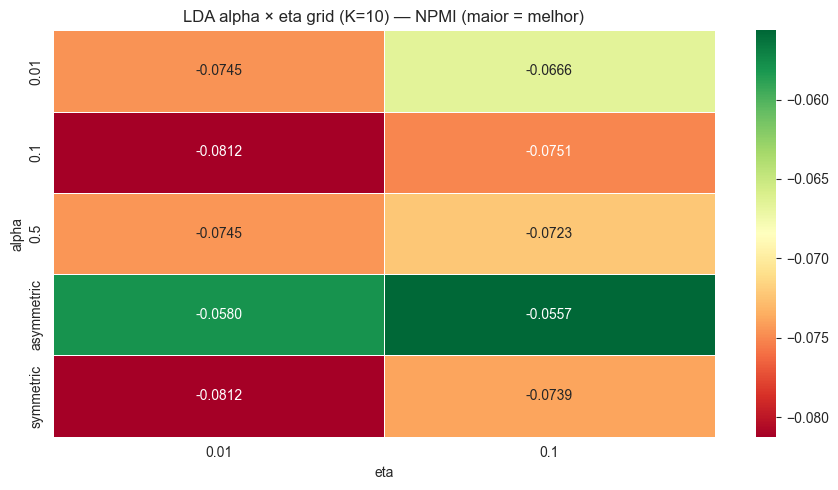


Treinando LDA K=10, alpha='asymmetric', eta=None, passes=20...


  done em 25s

Topics (top-10):
  T 0: ['bolsonaro', 'debatenaband', 'mané', 'brasil', 'lula', 'eduardo', 'perdeu', 'pra', 'amolar', 'perder']
  T 1: ['globolixo', 'bolsonaro', 'bolsonaronojn', 'bonner', 'forabolsonaro', 'hoje', 'presidente', 'renata', 'globo', 'entrevista']
  T 2: ['bolsonaro', 'casa', 'alvorada', 'capes', 'forabolsonaro', 'gente', 'lulapresidente', 'nacional', 'globolixo', 'falar']
  T 3: ['brasília', 'polícia', 'bolsonarista', 'federal', 'carro', 'terrorista', 'orçamento', 'secreto', 'bolsonaristas', 'esquerda']
  T 4: ['lula', 'presidente', 'bolsonaro', 'corte', 'bobo', 'brasil', 'deixar', 'país', 'governo', 'hoje']
  T 5: ['brasil', 'jair', 'lulapresidente', 'quebrou', 'bolsonaro', 'saqueou', 'hora', 'rombo', 'bilhões', 'vote']
  T 6: ['prender', 'cacique', 'mané', 'índio', 'perdeu', 'lula', 'dia', 'brasília', 'ser', 'amola']
  T 7: ['votar', 'federal', 'polícia', 'nordeste', 'rodoviária', 'deixem', 'eleitoral', 'crime', 'prf', 'impedir']
  T 8: ['fogo', 'bolsonar

In [12]:
# Cell 12 — Grid alpha/eta (K=BEST_K fixo) + treino final
# --- PROTOCOLO 2026-08-16 (docs/protocolo-selecao-final-2026-08-16.md, secoes 4.1 e 4.2.1)
#     ANTES: BEST_K = argmax(C_v) sobre a grade inteira. Dois problemas, medidos:
#     (a) o eixo errado — o C_v degenera onde a janela de 110 tokens nao cabe, e o
#         protocolo ordena por NPMI (Bouma 2009), que e o par canonico do BERTopic e
#         o unico estimador que nao muda de regime entre os nossos dois corpora;
#     (b) sem a faixa declarada de K (restricao A3), todo criterio testado desce para
#         o extremo grosso da grade (secao 3.2, resultado 3). A faixa e SUBSTANTIVA e
#         declarada ANTES de olhar a grade — vem de _selecao.py, fonte unica.
from _selecao import FAIXA_K, _decidir_curva_k
_k_min, _k_max = FAIXA_K[CORPUS_ID]
_k_admissiveis = [k for k in npmi_scores if _k_min <= k <= _k_max]
if not _k_admissiveis:
    raise ValueError(
        f"nenhum K da grade {sorted(npmi_scores)} cai na faixa declarada "
        f"[{_k_min},{_k_max}] para {CORPUS_ID} — revise a grade ou a faixa, "
        f"mas declare a mudanca antes de olhar os resultados"
    )
_curvas_k = {"NPMI": npmi_scores, "Diversity": div_scores}
BEST_K, _criterio_k = _decidir_curva_k(_curvas_k, _k_min, _k_max)
if BEST_K is None:
    raise ValueError(f"_decidir_curva_k nao achou K admissivel: {_criterio_k}")
_best_k_cv = max(_k_admissiveis, key=lambda k: scores[k])

print(f"Faixa de K declarada para {CORPUS_ID}: [{_k_min},{_k_max}] "
      f"({len(_k_admissiveis)} de {len(npmi_scores)} pontos admissiveis)")
print(f"BEST_K pelo protocolo (secao 1.5): {BEST_K}  (NPMI {npmi_scores[BEST_K]:+.4f})")
print(f"  criterio: {_criterio_k}")
if "FORA do protocolo" in _criterio_k:
    print("  !! sem curva de Diversity no grid — decisao caiu para NPMI puro (fora do protocolo)")
if _best_k_cv != BEST_K:
    print(f"  NOTA: por C_v o argmax na faixa seria K={_best_k_cv} "
          f"(C_v {scores[_best_k_cv]:.4f} vs {scores[BEST_K]:.4f} em K={BEST_K}).")
    print("  Divergencia entre eixos e informacao a reportar, nao erro. O NPMI decide.")

# Curva completa — reportar a CURVA, nao so o argmax (mapeamento secao 2.11: o argmax
# nao e estavel; a curva custa zero porque ja saiu do mesmo grid).
print("\n  K      NPMI       C_v   Perplex.   admissivel")
for _k in sorted(npmi_scores):
    _adm = "sim" if _k_min <= _k <= _k_max else " - "
    _pp = perplexity_scores.get(_k, float("nan"))
    print(f"  {_k:>3d}  {npmi_scores[_k]:+.4f}  {scores[_k]:.4f}  {_pp:9.1f}      {_adm}")

def _parse_ae_row(row):
    """Restaura tipos Python a partir de linha do CSV de cache."""
    alpha = str(row["alpha"])
    eta = row["eta"]
    if alpha not in ("symmetric", "asymmetric"):
        try: alpha = float(alpha)
        except: alpha = "symmetric"
    if pd.isna(eta) or str(eta) in ("None", "nan", ""):
        eta = None
    elif str(eta) != "auto":
        try: eta = float(eta)
        except: eta = None
    return alpha, eta

# Cache do grid alpha/eta: vive no diretorio-BASE lda/ (reutilizado entre runs)
_ae_cache = f"{BASE_OUTPUT_DIR}/lda_alpha_eta_grid.csv"
_alpha_grid = params["evaluation"].get("lda_alpha_grid", ["symmetric", "asymmetric", 0.1, 0.5])
_eta_grid   = params["evaluation"].get("lda_eta_grid", [None, 0.01, 0.1])

# --- PROTOCOLO 2026-08-16: o cache de alpha/eta e tao pegajoso quanto o de K
#     (mapeamento secao 2.11.A) e era lido incondicionalmente — o 2o estagio do grid
#     podia ser PULADO INTEIRO, reusando um cache pre-git pontuado por C_v. Agora ele
#     so vale se trouxer a coluna npmi, que e o eixo do protocolo. Invalidacao
#     declarada: ninguem precisa apagar arquivo na mao.
_ae_valido = False
if os.path.exists(_ae_cache):
    _ae_chk = pd.read_csv(_ae_cache)
    _tem_npmi = "npmi" in _ae_chk.columns and _ae_chk["npmi"].notna().any()
    # O grid de alpha/eta e condicionado a K. Um cache gravado para outro K e
    # simplesmente o grid errado, e ate 2026-08-16 nada registrava para qual K
    # ele fora computado — o run de 16/08 carregou um cache gravado por uma
    # execucao anterior sem que houvesse como conferir a correspondencia.
    _k_do_cache = (int(_ae_chk["best_k"].iloc[0])
                   if "best_k" in _ae_chk.columns and pd.notna(_ae_chk["best_k"].iloc[0])
                   else None)
    _mesmo_k = (_k_do_cache == BEST_K)
    _ae_valido = _tem_npmi and _mesmo_k
    if not _tem_npmi:
        print("Cache de alpha/eta sem coluna npmi (pre-protocolo 2026-08-16) — recomputando.")
    elif _k_do_cache is None:
        print("Cache de alpha/eta sem carimbo de K — nao da para saber se e deste K. Recomputando.")
    elif not _mesmo_k:
        print(f"Cache de alpha/eta e de K={_k_do_cache}, mas BEST_K={BEST_K} — recomputando.")

if _ae_valido:
    ae_df = pd.read_csv(_ae_cache)
    best_alpha, best_eta = _parse_ae_row(ae_df.iloc[0])
    print(f"Grid alpha/eta carregado do cache ({_ae_cache}).")
else:
    print(f"Grid alpha ({len(_alpha_grid)}) × eta ({len(_eta_grid)}) = {len(_alpha_grid)*len(_eta_grid)} combos, passes=10...")
    t0 = time.time()
    ae_df, best_alpha, best_eta = grid_search_alpha_eta(
        corpus_bow, dictionary, tokenized, BEST_K,
        alpha_grid=_alpha_grid, eta_grid=_eta_grid, seed=seed, passes=10,
        score_by="npmi",   # mesmo eixo do estagio 1 — o protocolo exige coerencia entre estagios
        checkpoint_path=BASE_OUTPUT_DIR / "lda_alpha_eta_checkpoint.csv",
    )
    ae_df = ae_df.assign(best_k=BEST_K)   # carimbo: o grid de alpha/eta e condicionado a K
    ae_df.to_csv(_ae_cache, index=False)
    print(f"  done em {time.time()-t0:.0f}s")

print(ae_df.to_string(index=False))
print(f"\n  ★ best_alpha={best_alpha!r}  best_eta={best_eta!r}")

# Heatmap C_v por alpha × eta
if len(ae_df) > 1:
    # heatmap no eixo que DECIDE (NPMI); o C_v segue na tabela impressa acima
    _pivot = ae_df.pivot_table(index="alpha", columns="eta", values="npmi", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(9, max(3, len(_pivot) * 0.8 + 1)))
    sns.heatmap(_pivot, annot=True, fmt=".4f", cmap="RdYlGn", ax=ax, linewidths=0.5)
    ax.set_title(f"LDA alpha × eta grid (K={BEST_K}) — NPMI (maior = melhor)")
    plt.tight_layout(); plt.show()

# Treino final com melhores hiperparâmetros
print(f"\nTreinando LDA K={BEST_K}, alpha={best_alpha!r}, eta={best_eta!r}, passes=20...")
t0 = time.time()
model = train_lda(corpus_bow, dictionary, k=BEST_K, seed=seed, passes=20, alpha=best_alpha, eta=best_eta)
print(f"  done em {time.time()-t0:.0f}s")

top_n = params["evaluation"]["top_n_keywords"]
topics_keywords = extract_topics_keywords(model, k=BEST_K, top_n=top_n)

print(f"\nTopics (top-{top_n}):")
for tid in sorted(topics_keywords):
    print(f"  T{tid:2d}: {topics_keywords[tid]}")

Salvo: ..\data\output\tweets_bre2022\lda\lda_grid_alpha_eta_heatmap.png


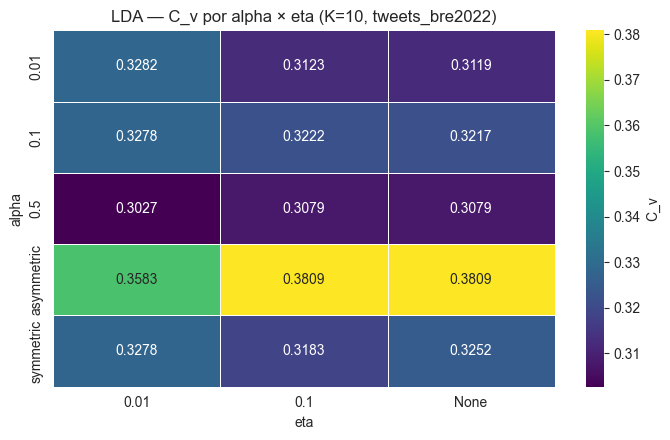

In [13]:
# Heatmap C_v do grid alpha x eta (lê o cache persistido no diretório-base)
_ae_csv = BASE_OUTPUT_DIR / "lda_alpha_eta_grid.csv"
if _ae_csv.exists():
    _g = pd.read_csv(_ae_csv)
    _g["eta"] = _g["eta"].fillna("None").astype(str)
    _g["alpha"] = _g["alpha"].astype(str)
    _piv = _g.pivot_table(index="alpha", columns="eta", values="cv")
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.heatmap(_piv, annot=True, fmt=".4f", cmap="viridis", linewidths=0.5, ax=ax,
                cbar_kws={"label": "C_v"})
    ax.set_title(f"LDA — C_v por alpha × eta (K={BEST_K}, {CORPUS_ID})")
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT_DIR / "lda_grid_alpha_eta_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {BASE_OUTPUT_DIR / 'lda_grid_alpha_eta_heatmap.png'}")
    plt.show()
else:
    print("Sem lda_alpha_eta_grid.csv — heatmap pulado")

## 7. Rotulagem via LLM (Ollama)

`_helpers.name_all_topics` envia as keywords pro modelo configurado em `params.yaml` (`llm.model`) via Ollama com prompt few-shot em PT-BR. Em ~9s/tópico em CPU. Fallback: top-3 keywords se Ollama indisponível.

In [14]:
# Cell 15 — Naming
llm_cfg = params.get("llm", {})
print(f"Naming via {llm_cfg.get('model')} ({BEST_K} tópicos × ~9s = ~{BEST_K*9}s)...")

t0 = time.time()
try:
    names = name_all_topics(
        topics_keywords,
        model=llm_cfg["model"],
        base_url=llm_cfg.get("base_url", "http://localhost:11434"),
    )
    print(f"  done em {time.time()-t0:.0f}s")
except Exception as e:
    print(f"  LLM falhou ({e}) — fallback top-3")
    names = {tid: ", ".join(kws[:3]) for tid, kws in topics_keywords.items()}

print()
for tid in sorted(names):
    print(f"  T{tid:2d}: {names[tid]}")
    print(f"        keywords: {topics_keywords[tid][:8]}")

Naming via gemma2:2b-instruct-q4_K_M (10 tópicos × ~9s = ~90s)...


  done em 30s

  T 0: Bolsonaro e Debate
        keywords: ['bolsonaro', 'debatenaband', 'mané', 'brasil', 'lula', 'eduardo', 'perdeu', 'pra']
  T 1: Globo e Bolsonaro
        keywords: ['globolixo', 'bolsonaro', 'bolsonaronojn', 'bonner', 'forabolsonaro', 'hoje', 'presidente', 'renata']
  T 2: Bolsonaro e Casa
        keywords: ['bolsonaro', 'casa', 'alvorada', 'capes', 'forabolsonaro', 'gente', 'lulapresidente', 'nacional']
  T 3: Brasília e Terrorismo
        keywords: ['brasília', 'polícia', 'bolsonarista', 'federal', 'carro', 'terrorista', 'orçamento', 'secreto']
  T 4: Luta Política Nacional
        keywords: ['lula', 'presidente', 'bolsonaro', 'corte', 'bobo', 'brasil', 'deixar', 'país']
  T 5: Saque em Brasil e Lula
        keywords: ['brasil', 'jair', 'lulapresidente', 'quebrou', 'bolsonaro', 'saqueou', 'hora', 'rombo']
  T 6: Lula e Cacique em Brasília
        keywords: ['prender', 'cacique', 'mané', 'índio', 'perdeu', 'lula', 'dia', 'brasília']
  T 7: Eleições e Segurança no

## 8. Visualização dos tópicos

Wordclouds + bar charts mostram a estrutura semântica de cada tópico. Escala logarítmica destaca palavras menos frequentes mas igualmente representativas.

Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814\lda_wordclouds.png


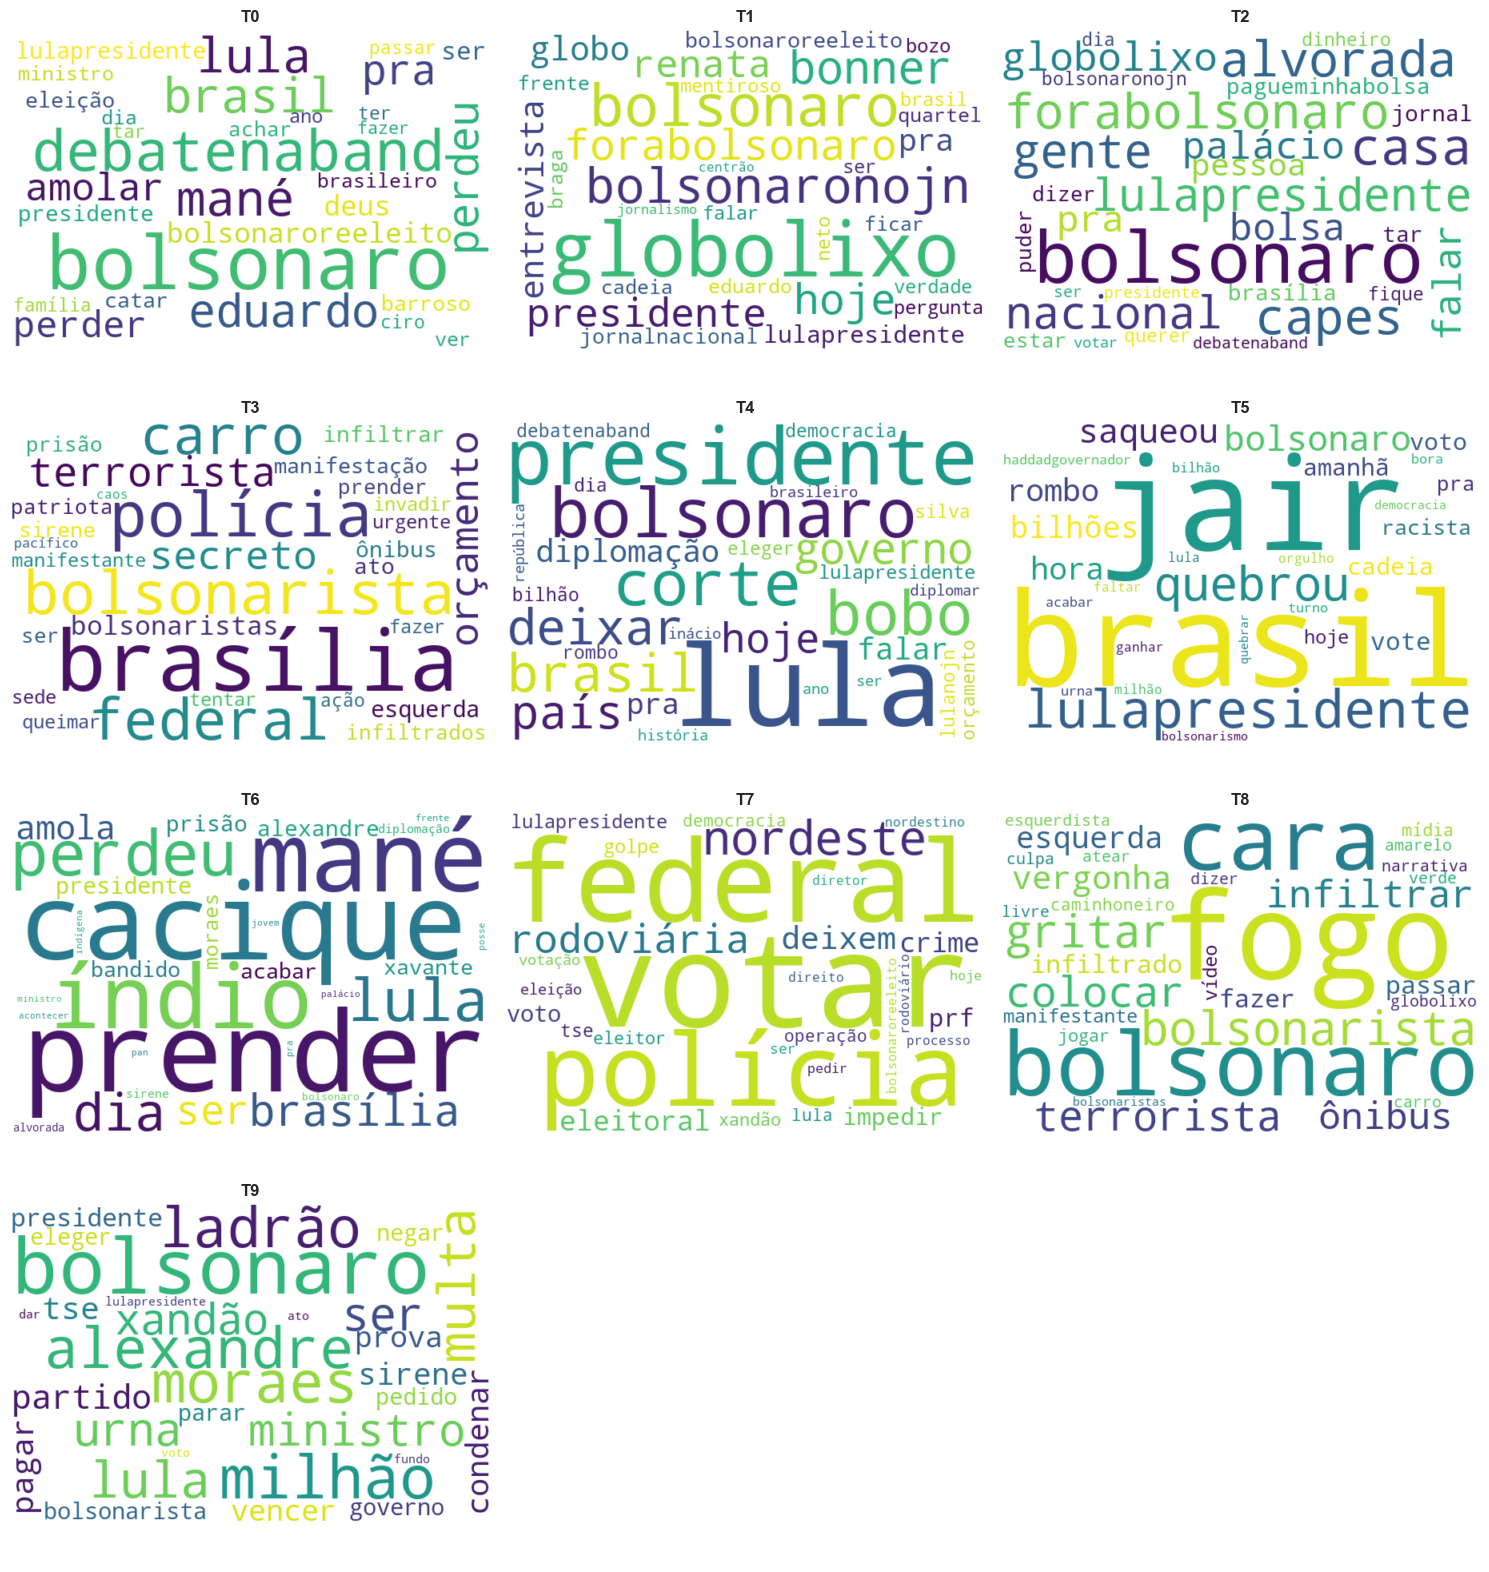

In [15]:
# Cell 13 — Wordclouds (1 por topico)
ncols = 3
nrows = (BEST_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

_dead_topics = []
for tid in sorted(topics_keywords):
    # gensim show_topic retorna (palavra, prob); usar prob como freq do wordcloud
    word_probs = dict(model.show_topic(tid, topn=30))
    # topico "morto" (sem massa de probabilidade, comum com K alto em texto curto):
    # show_topic pode retornar NaN quando a linha phi normaliza 0/0
    valid_probs = {w: p for w, p in word_probs.items() if np.isfinite(p) and p > 0}
    axes[tid].set_title(f"T{tid}", fontsize=12, fontweight="bold")
    axes[tid].axis("off")
    if not valid_probs:
        _dead_topics.append(tid)
        axes[tid].text(0.5, 0.5, "topico degenerado\n(sem massa de probabilidade)",
                       ha="center", va="center", fontsize=9, color="gray", wrap=True)
        continue
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", max_words=30, prefer_horizontal=0.9).generate_from_frequencies(valid_probs)
    axes[tid].imshow(wc, interpolation="bilinear")

# Esconde axes nao usados
for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_wordclouds.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'lda_wordclouds.png'}")
plt.show()

if _dead_topics:
    print(f"AVISO: {len(_dead_topics)} topico(s) degenerado(s) (sem massa de probabilidade): {_dead_topics}")
    print("  Indica K provavelmente alto demais para o vocabulario esparso deste corpus — considere revisar BEST_K.")


Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814\lda_keywords_barchart.png


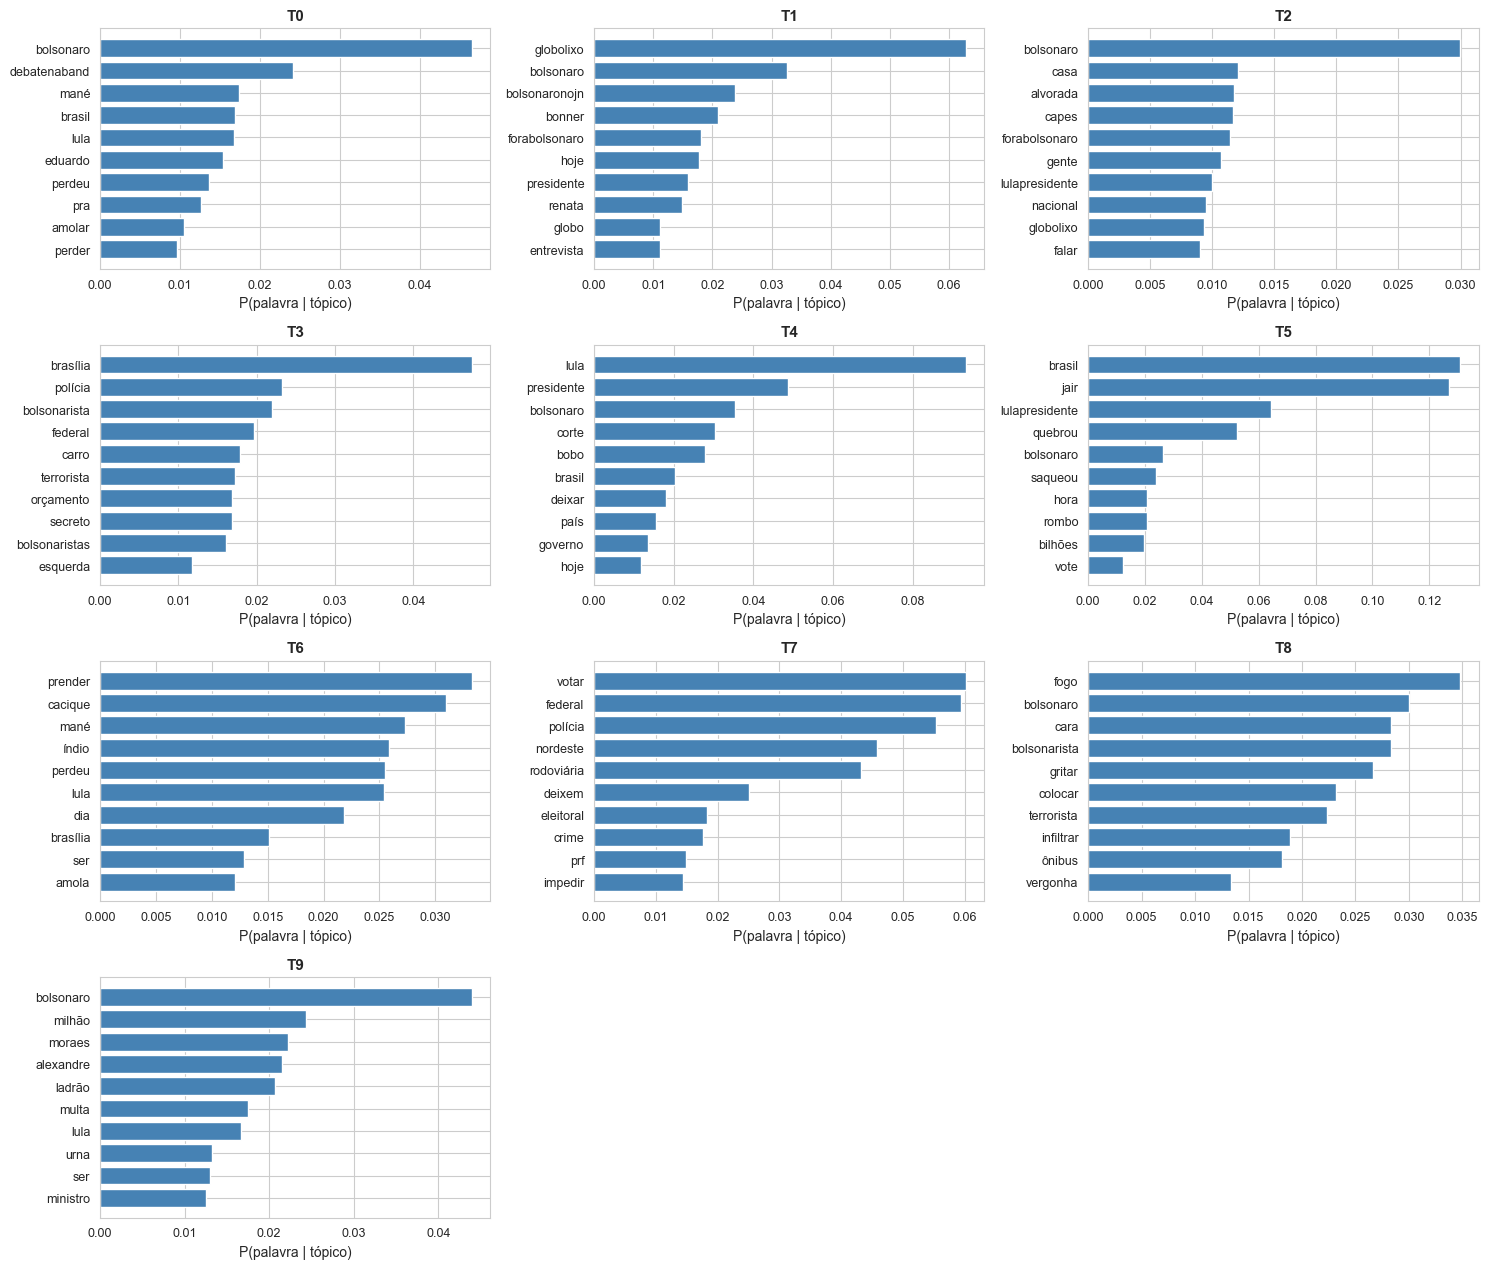

In [16]:
# Cell 14 — Bar chart top-10 keywords per topic
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

for tid in sorted(topics_keywords):
    word_probs = model.show_topic(tid, topn=10)
    words, probs = zip(*word_probs)
    axes[tid].barh(list(words)[::-1], list(probs)[::-1], color="steelblue")
    axes[tid].set_title(f"T{tid}", fontsize=11, fontweight="bold")
    axes[tid].set_xlabel("P(palavra | tópico)")
    axes[tid].tick_params(labelsize=9)

for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_keywords_barchart.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'lda_keywords_barchart.png'}")
plt.show()

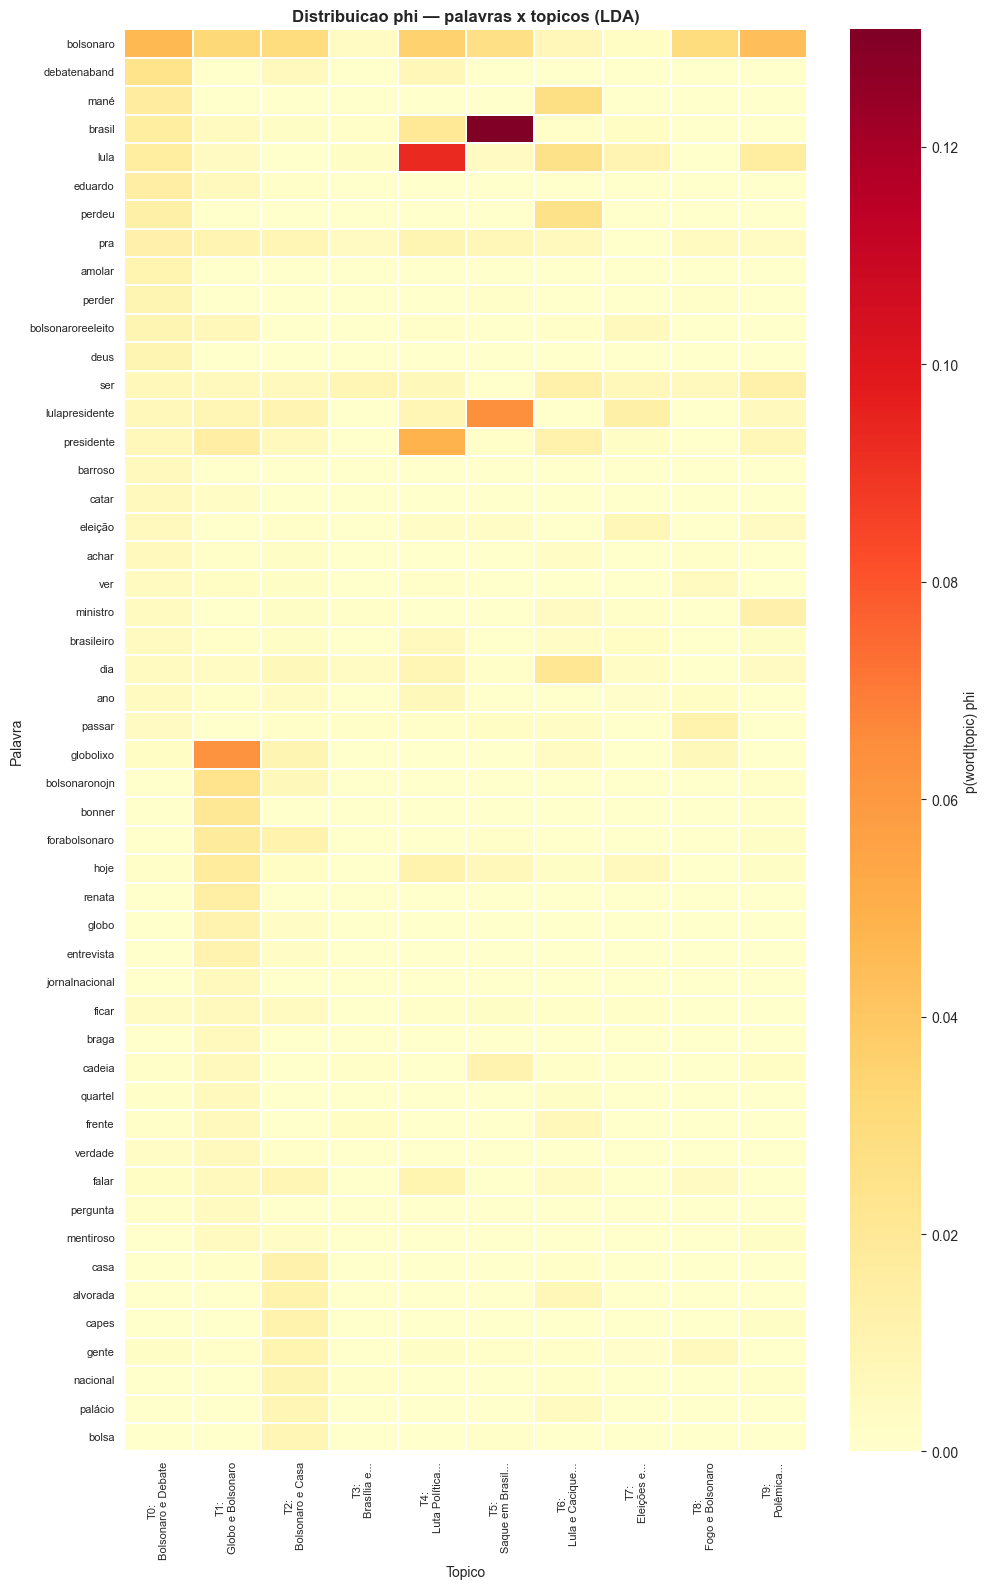

Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814\lda_heatmap_phi.png


In [17]:
import seaborn as sns
# Heatmap phi: top palavras x topicos
_top_n_phi = 25
_all_words = []
for tid in range(BEST_K):
    for w, _ in model.show_topic(tid, topn=_top_n_phi):
        if w not in _all_words:
            _all_words.append(w)
_all_words = _all_words[:min(50, len(_all_words))]

_phi = np.zeros((len(_all_words), BEST_K))
for tid in range(BEST_K):
    _td = dict(model.show_topic(tid, topn=200))
    for wi, w in enumerate(_all_words):
        _phi[wi, tid] = _td.get(w, 0.0)

import textwrap as _tw_lda
_col_labels = [f"T{t}:\n{_tw_lda.shorten(str(names.get(t,"")), 18, placeholder="...")}" for t in range(BEST_K)]
_phi_df = pd.DataFrame(_phi, index=_all_words, columns=_col_labels)

fig, ax = plt.subplots(figsize=(max(10, BEST_K * 0.8), max(8, len(_all_words) * 0.32)))
sns.heatmap(_phi_df, cmap="YlOrRd", ax=ax, linewidths=0.15,
            cbar_kws={"label": "p(word|topic) phi"})
ax.set_title("Distribuicao phi — palavras x topicos (LDA)", fontsize=12, fontweight="bold")
ax.set_xlabel("Topico"); ax.set_ylabel("Palavra")
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_heatmap_phi.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'lda_heatmap_phi.png'}")


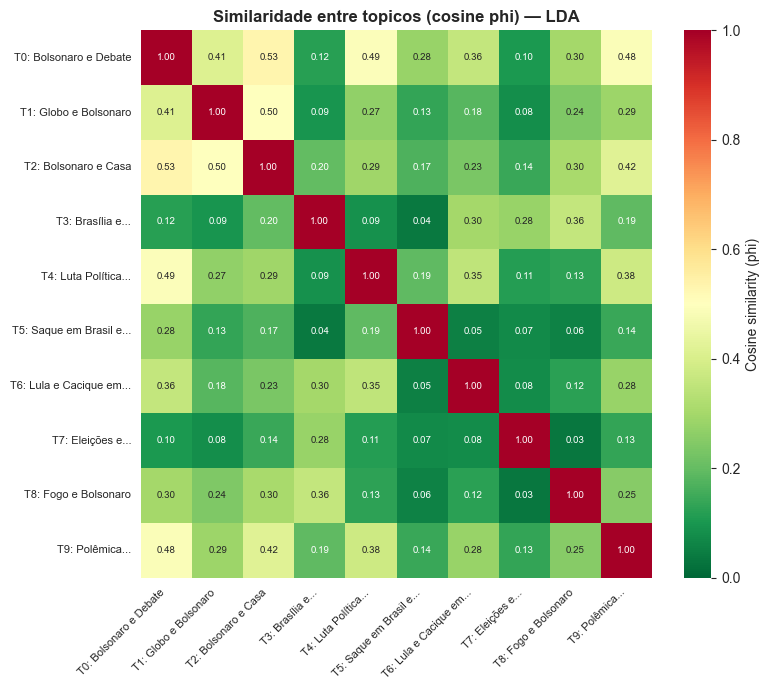

Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814\lda_heatmap_topicos_cosine.png


In [18]:
import seaborn as sns
# Similaridade cosseno entre topicos (vetores phi)
from sklearn.metrics.pairwise import cosine_similarity

_phi_topics = np.zeros((BEST_K, len(dictionary)))
for tid in range(BEST_K):
    for word_id, prob in model.get_topic_terms(tid, topn=len(dictionary)):
        _phi_topics[tid, word_id] = prob

# --- CORRECAO 2026-08-16: sanear NaN antes do cosine_similarity.
#     Um topico "morto" (sem massa) tem a linha do phi normalizada 0/0 -> NaN, e o
#     sklearn recusa a matriz inteira com "Input contains NaN", derrubando o run.
#     E o MESMO fenomeno que a celula de wordclouds ja tratava neste notebook: o
#     tratamento so nao havia sido propagado para ca. Os topicos mortos sao
#     reportados, nao silenciados -- sao diagnostico de K alto demais para o corpus.
_linhas_mortas = [t for t in range(BEST_K)
                  if not np.isfinite(_phi_topics[t]).all() or _phi_topics[t].sum() <= 0]
if _linhas_mortas:
    print(f"ATENCAO: {len(_linhas_mortas)} de {BEST_K} topicos sem massa de "
          f"probabilidade no phi: {_linhas_mortas}")
    print("  Sao topicos degenerados -- sinal de que K esta alto para este corpus.")
    print("  Entram na figura como linha/coluna zerada; declarar no texto.")
_phi_topics = np.nan_to_num(_phi_topics, nan=0.0, posinf=0.0, neginf=0.0)

_cos_sim = cosine_similarity(_phi_topics)
import textwrap as _tw_cos
_tlabels = [f"T{t}: {_tw_cos.shorten(str(names.get(t,"")), 20, placeholder="...")}" for t in range(BEST_K)]

fig, ax = plt.subplots(figsize=(max(8, BEST_K * 0.65), max(7, BEST_K * 0.6)))
sns.heatmap(_cos_sim, xticklabels=_tlabels, yticklabels=_tlabels,
            cmap="RdYlGn_r", vmin=0, vmax=1,
            annot=(BEST_K <= 20), fmt=".2f", ax=ax,
            annot_kws={"fontsize": 7},
            cbar_kws={"label": "Cosine similarity (phi)"})
ax.set_title("Similaridade entre topicos (cosine phi) — LDA", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_heatmap_topicos_cosine.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'lda_heatmap_topicos_cosine.png'}")


## 9. Métricas quantitativas

- **c_v** recomputada (validação cruzada do grid)
- **Exclusivity**: 1 - prop. de keywords compartilhadas entre tópicos
- **Topic Diversity**: razão de palavras únicas no consolidado dos top-K
- **Diversity entropy** das distribuições θ doc-tópico (quão espalhadas)

Calculando métricas...


  Perplexidade: 1014.6 (menor = melhor fit)


  [C_v] NAO REPORTADO: 100.0% dos documentos tem menos de 110 tokens (mediana 9). A janela deslizante degenera e o valor deixa de ser o C_v de Roder et al. Valor bruto = 0.4806; use o NPMI.
  NPMI (top-10): +0.0324  |  C_v: 0.4806  |  regime C_v: DEGENERADO - nao publicar sob o rotulo C_v


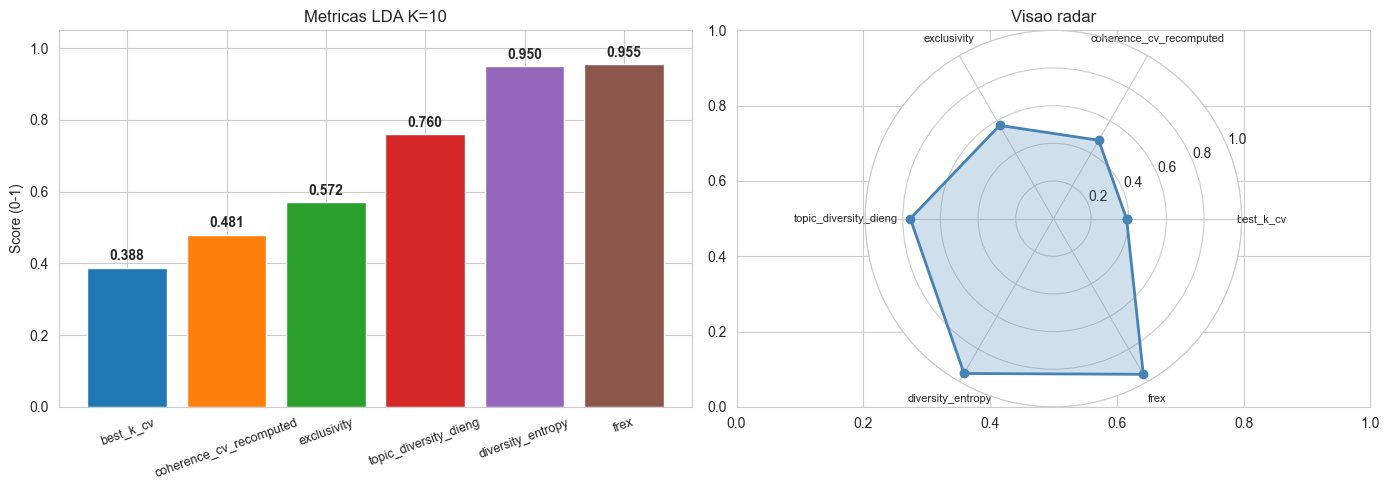

{
  "model": "lda",
  "topic_type": "probabilistic",
  "granularity": "unit",
  "corpus": "tweets_bre2022",
  "corpus_version": "n/a",
  "n_topics": 10,
  "best_k_cv": 0.3882596002820249,
  "exclusivity": 0.571687944127216,
  "diversity_entropy": 0.9497572941123777,
  "topic_diversity_dieng": 0.76,
  "frex": 0.9548473799241737,
  "perplexity": 1014.6483618921139,
  "coherence_cv_recomputed": 0.4806246754075036,
  "coherence_npmi": 0.0323787771456261,
  "metrics_top_n": 10,
  "cv_regime_ok": false,
  "cv_window_frac_abaixo": 1.0,
  "oov_taxa": 0.0,
  "n_topicos_descartados_coerencia": 0
}


In [19]:
# Cell 16 — Calcula metricas
print("Calculando métricas...")
dominant, full = compute_doc_distributions(model, corpus_bow, k=BEST_K)

# FREX — phi matrix do gensim (K x vocab_size)
_phi = model.get_topics()  # shape (BEST_K, vocab_size)
_vocab_idx = {dictionary[i]: i for i in range(len(dictionary))}
_topic_idx = {tid: tid for tid in range(BEST_K)}
_top_n_metrics = params["evaluation"].get("top_n_keywords_metrics", 20)
frex_mean, frex_per_topic = compute_frex_score(
    topics_keywords, _phi, _vocab_idx, _topic_idx, top_n=_top_n_metrics,
)

# Exclusividade c-TF-IDF (MESMA metrica dos outros 7 runs de producao) - scores da phi completa
_topic_word_scores_lda = {
    tid: {dictionary[i]: float(_phi[tid, i]) for i in range(_phi.shape[1]) if _phi[tid, i] > 0}
    for tid in range(BEST_K)
}
_excl_mean, _excl_per_topic = compute_exclusivity_ctfidf(
    topics_keywords, _topic_word_scores_lda, top_n=_top_n_metrics,
)

# Perplexidade — log_perplexity retorna bound por palavra (ln), exp para perplexidade
perplexity = float(np.exp(-model.log_perplexity(corpus_bow)))
print(f"  Perplexidade: {perplexity:.1f} (menor = melhor fit)")

metrics = {
    "model": "lda",
    "topic_type": "probabilistic",
    "granularity": "unit",
    "corpus": CORPUS_ID,
    "corpus_version": globals().get("CORPUS_VERSION", "n/a"),
    "n_topics": BEST_K,
    "best_k_cv": float(scores.get(BEST_K, 0.0)),
    "exclusivity": float(_excl_mean),
    "diversity_entropy": float(compute_diversity(full)),
    "topic_diversity_dieng": float(compute_topic_diversity(topics_keywords)),
    "frex": float(frex_mean),
    "perplexity": perplexity,
}
metrics["coherence_cv_recomputed"] = float(compute_coherence_cv(topics_keywords, tokenized, dictionary))

# --- ADICAO 2026-08-16 (protocolo de selecao, docs/protocolo-selecao-final-2026-08-16.md).
#     NPMI passa a ser a coerencia que DECIDE; o C_v vira reporte condicionado ao regime
#     de janela (secao 3.0) e o filtro de OOV passa a ser quantificado. Aditivo: nenhum
#     valor preexistente muda. compute_metrics_table e o MESMO codigo chamado pelo
#     _metricas_pos_hoc.py, que preenche os runs ja existentes sem re-executar nada.
_tn_base = max(len(kws) for kws in topics_keywords.values())
_tab = compute_metrics_table(
    topics_keywords, tokenized, dictionary, top_n=_tn_base,
    topic_word_scores=_topic_word_scores_lda,
    topic_word_matrix=_phi, vocab_index=_vocab_idx, topic_index=_topic_idx,
)
assert abs(_tab["cv_bruto"] - metrics["coherence_cv_recomputed"]) < 1e-9, (
    "compute_metrics_table divergiu do calculo direto de C_v - investigar antes de publicar"
)
metrics["coherence_npmi"] = _tab["npmi"]
metrics["metrics_top_n"] = _tab["top_n"]
metrics["cv_regime_ok"] = not _tab["cv_window_degenerado"]
metrics["cv_window_frac_abaixo"] = _tab["cv_window_frac_abaixo"]
metrics["oov_taxa"] = _tab["oov_taxa"]
metrics["n_topicos_descartados_coerencia"] = _tab["n_topicos_descartados"]
_regime = "OK" if metrics["cv_regime_ok"] else "DEGENERADO - nao publicar sob o rotulo C_v"
print("  NPMI (top-%d): %+.4f  |  C_v: %.4f  |  regime C_v: %s"
      % (_tn_base, _tab["npmi"], metrics["coherence_cv_recomputed"], _regime))


# Visualiza num radar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
# NAO acrescentar "coherence_npmi" a esta lista: o NPMI vive em [-1, 1] e o eixo abaixo
# e set_ylim(0, 1.05) - um valor negativo sairia invisivel, sem levantar erro.
metric_keys = ["best_k_cv", "coherence_cv_recomputed", "exclusivity",
               "topic_diversity_dieng", "diversity_entropy", "frex"]
metric_vals = [metrics[k] for k in metric_keys]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
axes[0].bar(metric_keys, metric_vals, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score (0-1)")
axes[0].set_title(f"Metricas LDA K={BEST_K}")
axes[0].tick_params(axis="x", rotation=20, labelsize=9)
for i, (k, v) in enumerate(zip(metric_keys, metric_vals)):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

# Radar
angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
vals = metric_vals + [metric_vals[0]]
angles_p = angles + [angles[0]]
axes[1] = plt.subplot(122, projection="polar")
axes[1].plot(angles_p, vals, "o-", linewidth=2, color="steelblue")
axes[1].fill(angles_p, vals, alpha=0.25, color="steelblue")
axes[1].set_xticks(angles); axes[1].set_xticklabels(metric_keys, fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title("Visao radar")

plt.tight_layout(); plt.show()
print(json.dumps(metrics, indent=2))

=== Robustez por top-N (LDA) ===
 top_n    NPMI    C_v  Topic_Diversity  Exclusivity   FREX
    10  0.0324 0.4806           0.7600       0.5717 0.9548
    15 -0.0002 0.4396           0.7067       0.5255 0.9476
    20 -0.0308 0.4170           0.6750       0.5002 0.9463
    25 -0.0415 0.3982           0.6600       0.4931 0.9426
    30 -0.0494 0.3857           0.6433       0.4837 0.9407
    50 -0.1164 0.3635           0.6220       0.4666 0.9368
   100 -0.2245 0.4647           0.5840       0.4408 0.9279

C_v top-10 = 0.4806   |   C_v top-20 = 0.4170
conferencia: coherence_cv_recomputed (top-10) = 0.4806


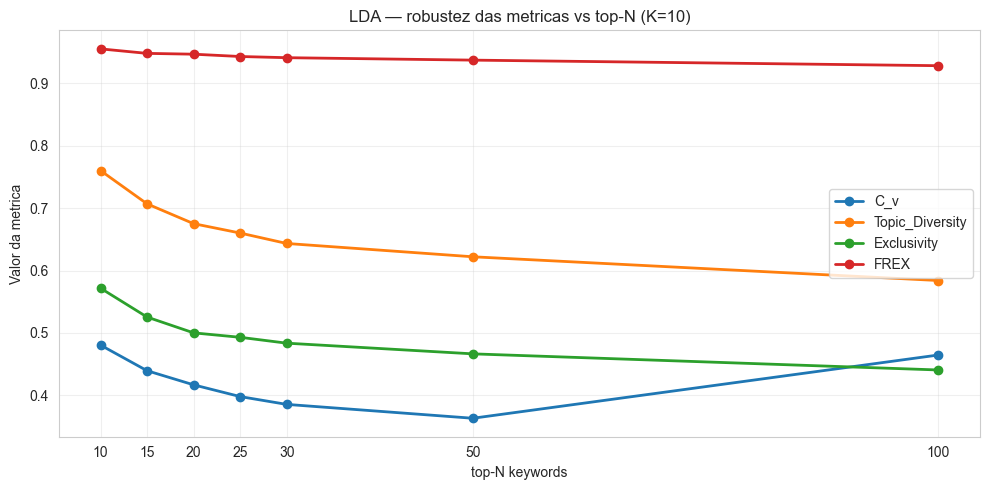

Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814/lda_robustness_topn.csv
Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814/lda_robustness_topn.png


In [20]:
# Cell 16b — Robustez por top-N (espelha a camada 5 do protocolo do BERTopic)
# POR QUE (2026-08-12): o LDA so materializava 10 keywords por topico, entao o C_v
# publicado era top-10 — mas era comparado com o do BERTopic, reportado em top-20.
# Bases distintas. Esta celula recomputa as metricas em cada base do sweep, para que
# a comparacao entre os dois modelos passe a existir na MESMA base.
_sweep_values = params["evaluation"].get("robustness_top_n_sweep", [10, 15, 20, 25, 30, 50, 100])
topics_keywords_full = extract_topics_keywords(model, k=BEST_K, top_n=max(_sweep_values))
_has_frex = "_vocab_idx" in globals() and "_topic_idx" in globals()

_rob_rows = []
for _tn in _sweep_values:
    _kws_at_n = {tid: kws[:_tn] for tid, kws in topics_keywords_full.items()}
    try:
        _cv_n = float(compute_coherence_cv(_kws_at_n, tokenized, dictionary))
    except Exception as _e:
        print(f"  [top-{_tn}] C_v falhou: {_e}")
        _cv_n = float("nan")
    try:
        _npmi_n = float(compute_coherence_npmi(_kws_at_n, tokenized, dictionary))
    except Exception as _e:
        print("  [top-%d] NPMI falhou: %s" % (_tn, _e))
        _npmi_n = float("nan")
    _td_n = float(compute_topic_diversity(_kws_at_n, top_k=_tn))
    _ex_n, _ = compute_exclusivity_ctfidf(topics_keywords_full, _topic_word_scores_lda, top_n=_tn)
    _row = {"top_n": _tn, "NPMI": _npmi_n, "C_v": _cv_n,
            "Topic_Diversity": _td_n, "Exclusivity": float(_ex_n)}
    if _has_frex:
        # FREX fica na tabela por paridade com o BERTopic, mas NAO deve ser lido como
        # nota de modelo: satura ~0.98 por construcao (auditoria 2026-08-01).
        _fx_n, _ = compute_frex_score(topics_keywords_full, _phi, _vocab_idx, _topic_idx, top_n=_tn)
        _row["FREX"] = float(_fx_n)
    _rob_rows.append(_row)

robustness_df = pd.DataFrame(_rob_rows).round(4)
robustness_df.to_csv(f"{out_dir}/lda_robustness_topn.csv", index=False)

print("=== Robustez por top-N (LDA) ===")
print(robustness_df.to_string(index=False))
_cv10 = robustness_df.loc[robustness_df["top_n"] == 10, "C_v"].iloc[0]
_cv20 = robustness_df.loc[robustness_df["top_n"] == 20, "C_v"].iloc[0]
print("")
print(f"C_v top-10 = {_cv10:.4f}   |   C_v top-20 = {_cv20:.4f}")
print(f"conferencia: coherence_cv_recomputed (top-10) = {metrics['coherence_cv_recomputed']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for _col in [c for c in ["C_v", "Topic_Diversity", "Exclusivity", "FREX"] if c in robustness_df]:
    ax.plot(robustness_df["top_n"], robustness_df[_col], marker="o", label=_col, linewidth=2)
ax.set_xlabel("top-N keywords"); ax.set_ylabel("Valor da metrica")
ax.set_title(f"LDA — robustez das metricas vs top-N (K={BEST_K})")
ax.legend(loc="best"); ax.grid(True, alpha=0.3); ax.set_xticks(_sweep_values)
plt.tight_layout()
plt.savefig(f"{out_dir}/lda_robustness_topn.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {out_dir}/lda_robustness_topn.csv")
print(f"Salvo: {out_dir}/lda_robustness_topn.png")


In [21]:
# Cell 16c — A2: estabilidade multi-seed (protocolo secao 1.1)
# DECISAO 2026-08-23: nao roda mais em nenhum braco. A selecao e a publicacao
# incidem sobre a seed 42, apenas (protocolo secao 1.1) — nao ha "estabilidade
# entre seeds" a medir quando so existe uma seed. O refit em 3 seeds que este
# passo fazia (A2, "Estabilidade dos topicos a K fixo") era o unico ponto do
# notebook que ainda levava 3x LdaMulticore(workers=None) sequenciais — a
# causa mais provavel do kernel morrer ~84min dentro da execucao (ledger
# Task 8, 2026-08-23: 'pressao de memoria dos 15 workers acumulada nos
# refits da etapa multi-seed').
print("Estabilidade multi-seed: DESATIVADA (protocolo secao 1.1 — selecao roda so sobre a seed 42).")


Estabilidade multi-seed: DESATIVADA (protocolo secao 1.1 — selecao roda so sobre a seed 42).


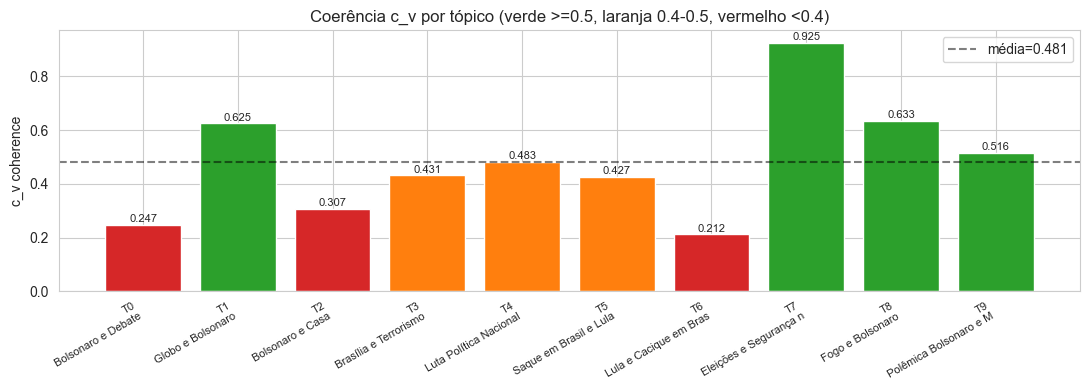

In [22]:
# Cell 17 — c_v por topico (nao so media)
from gensim.models import CoherenceModel
cm = CoherenceModel(
    topics=[topics_keywords[tid] for tid in sorted(topics_keywords)],
    texts=tokenized, dictionary=dictionary, coherence="c_v",
)
per_topic_cv = cm.get_coherence_per_topic()

fig, ax = plt.subplots(figsize=(11, 4))
tids = sorted(topics_keywords)
labels = [f"T{tid}\n{names[tid][:22]}" for tid in tids]
bars = ax.bar(tids, per_topic_cv, color=["#2ca02c" if c >= 0.5 else "#ff7f0e" if c >= 0.4 else "#d62728" for c in per_topic_cv])
ax.axhline(np.mean(per_topic_cv), color="black", linestyle="--", alpha=0.5, label=f"média={np.mean(per_topic_cv):.3f}")
ax.set_xticks(tids); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("c_v coherence"); ax.set_title("Coerência c_v por tópico (verde >=0.5, laranja 0.4-0.5, vermelho <0.4)")
ax.legend()
for bar, c in zip(bars, per_topic_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{c:.3f}",
            ha="center", fontsize=8)
plt.tight_layout(); plt.show()

## 10. Distribuição de documentos por tópico

Mostra balanceamento dos clusters. Distribuição muito desigual pode indicar:
- 1 tópico "lixo" capturando outliers
- K muito alto fragmentando o sinal
- Picos de discurso eleitoral concentrados em poucos temas dominantes (esperado em corpus político)

Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814\lda_docs_por_topico.png


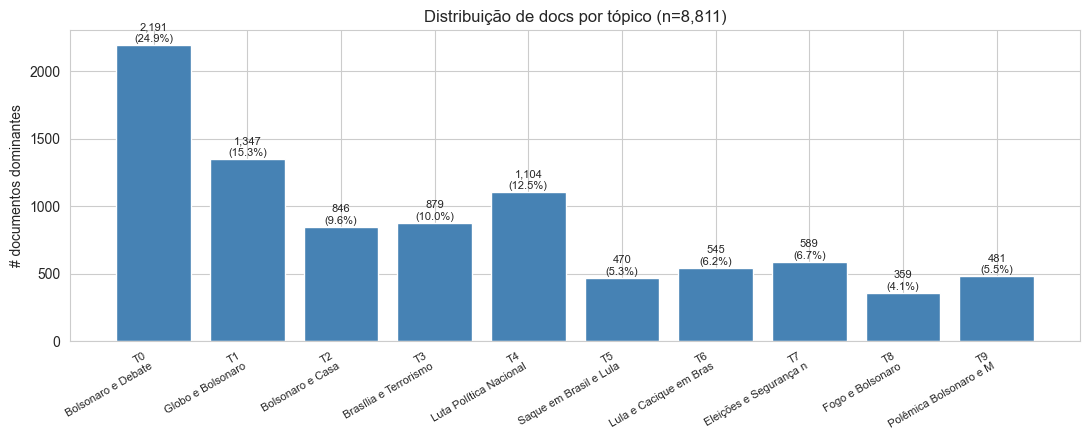


Docs por tópico — descritivas: {'count': 10.0, 'mean': 881.1, 'std': 556.1553440062108, 'min': 359.0, '25%': 497.0, '50%': 717.5, '75%': 1047.75, 'max': 2191.0}


In [23]:
# Cell 18 — Bar chart docs por topico
topic_doc_counts = pd.Series(dominant).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
labels = [f"T{tid}\n{names[tid][:22]}" for tid in topic_doc_counts.index]
bars = ax.bar(topic_doc_counts.index, topic_doc_counts.values, color="steelblue")
ax.set_xticks(topic_doc_counts.index); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("# documentos dominantes")
ax.set_title(f"Distribuição de docs por tópico (n={len(docs):,})")
for bar, c in zip(bars, topic_doc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + max(topic_doc_counts)*0.01,
            f"{c:,}\n({c/len(docs)*100:.1f}%)", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_docs_por_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'lda_docs_por_topico.png'}")
plt.show()

print(f"\nDocs por tópico — descritivas: {topic_doc_counts.describe().to_dict()}")

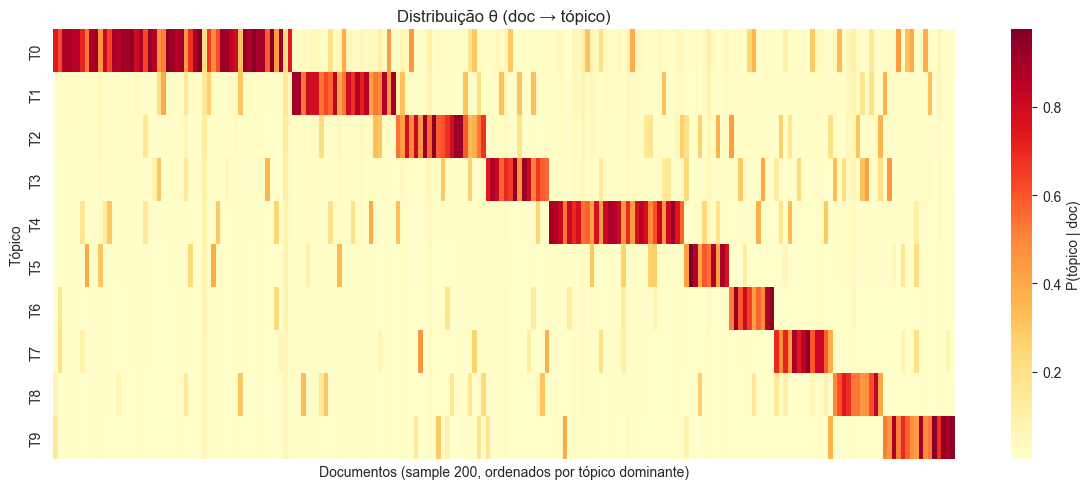

In [24]:
# Cell 19 — Heatmap theta (doc x topico) — sample
sample_n = min(200, len(full))
sample_idx = np.random.RandomState(42).choice(len(full), sample_n, replace=False)
theta_sample = np.array([full[i] for i in sample_idx])

# Sort sample by dominant topic for readability
sample_dom = theta_sample.argmax(axis=1)
order = np.argsort(sample_dom)
theta_sorted = theta_sample[order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(theta_sorted.T, cmap="YlOrRd", cbar_kws={"label": "P(tópico | doc)"},
            xticklabels=False, yticklabels=[f"T{i}" for i in range(BEST_K)], ax=ax)
ax.set_xlabel(f"Documentos (sample {sample_n}, ordenados por tópico dominante)")
ax.set_ylabel("Tópico"); ax.set_title("Distribuição θ (doc → tópico)")
plt.tight_layout(); plt.show()

## t-SNE do espaço de tópicos (θ)

Reduz a matriz θ (N×K) a 2D via t-SNE. Gera PNG colorido por tópico dominante e versão HTML interativa com hover do texto.

Calculando t-SNE sobre matriz theta...


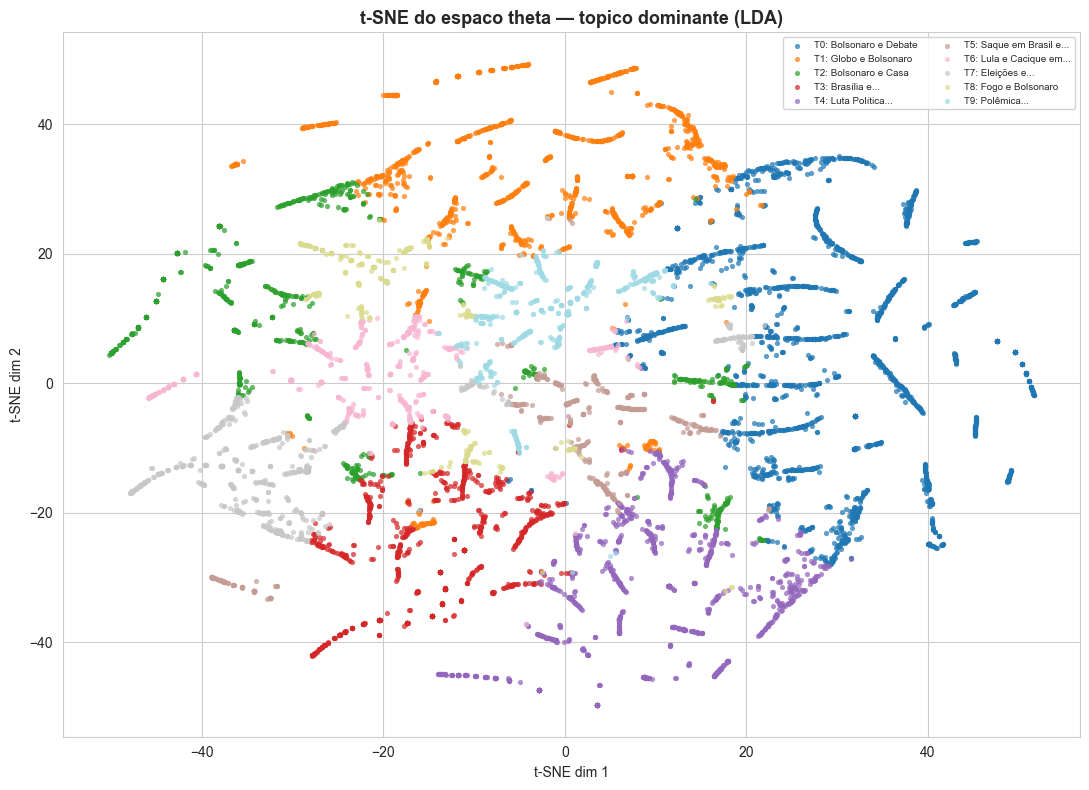

Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814\lda_tsne_theta_topico.png


Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814\lda_tsne_theta_interactive.html


In [25]:
import plotly.express as px
from sklearn.manifold import TSNE

_theta_mat = np.array(full)  # (n_docs, K)
_texts_lda = [t[:100] + "..." if len(t) > 100 else t for t in docs]

print("Calculando t-SNE sobre matriz theta...")
_tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=500)
_theta_2d = _tsne.fit_transform(_theta_mat)

_cmap_lda = plt.get_cmap("tab20", max(BEST_K, 1))

# PNG por topico dominante
fig, ax = plt.subplots(figsize=(11, 8))
for tid in range(BEST_K):
    _mm = np.array(dominant) == tid
    if _mm.any():
        import textwrap as _tw_u
        _nm = _tw_u.shorten(str(names.get(tid, "")), 20, placeholder="...")
        ax.scatter(_theta_2d[_mm, 0], _theta_2d[_mm, 1],
                   c=[_cmap_lda(tid)], s=14, alpha=0.72, linewidths=0,
                   label=f"T{tid}: {_nm}")
ax.set_title("t-SNE do espaco theta — topico dominante (LDA)", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="best", fontsize=7, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lda_tsne_theta_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'lda_tsne_theta_topico.png'}")

# HTML interativo por topico dominante
import textwrap as _tw_u2
_tsne_df_lda = pd.DataFrame({
    "x": _theta_2d[:, 0], "y": _theta_2d[:, 1],
    "Texto": _texts_lda,
    "Topico": [f"T{t}: {_tw_u2.shorten(str(names.get(t,"")), 25, placeholder="...")}" for t in dominant],
})
fig_u = px.scatter(
    _tsne_df_lda, x="x", y="y", color="Topico",
    hover_data={"x": False, "y": False, "Texto": True},
    title="t-SNE espaco theta — topico dominante (interativo, LDA)",
    labels={"x": "t-SNE dim 1", "y": "t-SNE dim 2"}, opacity=0.72,
)
fig_u.update_traces(marker_size=5)
_out_u = OUTPUT_DIR / "lda_tsne_theta_interactive.html"
fig_u.write_html(_out_u)
fig_u.show()
print(f"Salvo: {_out_u}")


## Cross-tab tópico × mês

Para os tweets, a "categoria" é o mês eleitoral (YYYY-MM) — mesmo eixo usado
pela fórmula de prevalência do STM. Mostra deslocamento da agenda ao longo da
campanha (1º turno → 2º turno → pós-eleição).

Salvo: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814\lda_topic_category.png


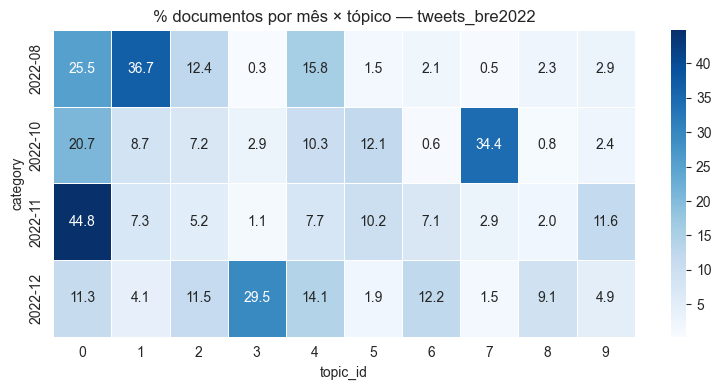

In [26]:
# Heatmap tópico × mês — tweets (category = YYYY-MM; deriva da data se ausente)
df_topic = df.copy()
if 'category' not in df_topic.columns and 'data' in df_topic.columns:
    df_topic['category'] = pd.to_datetime(df_topic['data'], errors='coerce').dt.to_period('M').astype(str)
if 'category' in df_topic.columns:
    df_topic = df_topic[['category']].assign(topic_id=dominant)
    df_topic = df_topic[df_topic['topic_id'] != -1]
    pivot = df_topic.groupby(['category', 'topic_id']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*0.8), max(4, len(pivot)*0.5)))
    sns.heatmap(pivot_pct.round(1), annot=True, fmt='.1f', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title('% documentos por mês × tópico — tweets_bre2022')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'lda_topic_category.png', dpi=150)
    print(f"Salvo: {OUTPUT_DIR / 'lda_topic_category.png'}")
    plt.show()
else:
    print('Sem coluna category/data — cross-tab pulado')

## 12. pyLDAvis — visualização interativa

Visualização canônica do LDA (Sievert & Shirley 2014). Mostra:
- **Esquerda**: tópicos como círculos no plano 2D (PCA do espaço inter-tópico). Tamanho = prevalência. Distância = dissimilaridade.
- **Direita**: bar chart das top-30 palavras do tópico selecionado, com slider λ controlando "exclusivity vs frequency" (Bischof & Airoldi 2016 — base do FREX score).

In [27]:
# Cell 21 — pyLDAvis (interativo, salva HTML)
import pyLDAvis
import pyLDAvis.gensim_models as gensim_pyLDAvis

pyLDAvis.enable_notebook()

print("Preparing pyLDAvis (~30s)...")
vis_data = gensim_pyLDAvis.prepare(model, corpus_bow, dictionary, sort_topics=False)
out_html = f"{out_dir}/lda_pyldavis_K{BEST_K}.html"
pyLDAvis.save_html(vis_data, out_html)
print(f"saved: {out_html}")
vis_data

Preparing pyLDAvis (~30s)...


saved: ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814/lda_pyldavis_K10.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.075677  0.078302       1        1  21.807538
1      0.046697  0.112135       2        1  12.776734
2      0.038740  0.080303       3        1  10.286294
3     -0.257662 -0.086330       4        1  11.559558
4      0.160165  0.030752       5        1  11.825552
5      0.207493 -0.057971       6        1   5.315305
6     -0.063175  0.035575       7        1   6.715450
7     -0.027219 -0.294489       8        1   8.215405
8     -0.205960  0.163274       9        1   4.972241
9      0.025245 -0.061551      10        1   6.525924, topic_info=                Term         Freq        Total Category  logprob  loglift
30            brasil  1186.000000  1186.000000  Default  30.0000  30.0000
330             jair   575.000000   575.000000  Default  29.0000  29.0000
87              lula  1596.000000  1596.000000  Default  28.0000  28.0000
697          polícia   600.000000   600.000000  Default  27.0000  27.0000
694          federal   606.000000   606.000000  Default  26.0000  26.0000
...              ...          ...          ...      ...      ...      ...
1480    bolsonarista    34.613783   422.930234  Topic10  -5.0441   0.2264
810              dar    29.611117   154.399877  Topic10  -5.2002   1.0780
881              ato    29.903198   179.549679  Topic10  -5.1904   0.9369
1952  lulapresidente    31.956287   788.826708  Topic10  -5.1240  -0.4768
1060            voto    29.052292   245.967850  Topic10  -5.2193   0.5933

[673 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
560       1  0.931767   abençoar
880       9  0.866166  abordagem
27        1  0.158164     acabar
27        2  0.120949     acabar
27        3  0.013956     acabar
...     ...       ...        ...
1616      1  0.005305     ônibus
1616      3  0.005305     ônibus
1616      4  0.562329     ônibus
1616      8  0.031830     ônibus
1616      9  0.392569     ônibus

[1751 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

## 13. Top documentos por tópico

Mostra os 3 docs com maior probabilidade em cada tópico — verificação qualitativa direta da semântica.

In [28]:
# Cell 22 — Top 3 docs por topico
TOP_N_DOCS = 3
TRUNC = 200

theta_arr = np.array(full)
print("Top docs por topico (truncados em 200 chars):\n")
for tid in sorted(topics_keywords):
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:TOP_N_DOCS]
    print(f"=== T{tid} [{names[tid]}] ===")
    print(f"  keywords: {topics_keywords[tid][:8]}\n")
    for rank, idx in enumerate(top_idx, 1):
        prob = theta_arr[idx, tid]
        cat = df.iloc[idx]["category"]
        text = df.iloc[idx]["message"][:TRUNC].replace("\n", " ")
        print(f"  #{rank} (P={prob:.3f}, cat={cat}): {text}...")
        print()

Top docs por topico (truncados em 200 chars):

=== T0 [Bolsonaro e Debate] ===
  keywords: ['bolsonaro', 'debatenaband', 'mané', 'brasil', 'lula', 'eduardo', 'perdeu', 'pra']

  #1 (P=0.969, cat=2022-08): "Eu estava na CPI, estudei os documentos, atraso de 45 dias na compra de vacina. Quantas famílias perderam os filhos e filhos perderam pais? Não vi o presidente pegar a moto dele e entrar em 1 hospita...

  #2 (P=0.967, cat=2022-11): @LUIZPATRIOTA39 Você viu o Eduardo Bolsonaro na Copa?? - Vi, e daí!? - Você vai continuar na rua, na chuva e ele passeando no Qatar!? - Claro! Não tô na rua por causa do Eduardo Bolsonaro nem por caus...

  #3 (P=0.967, cat=2022-11): - Você viu o Eduardo Bolsonaro na Copa?? - Vi, e daí!? - Você vai continuar na rua, na chuva e ele passeando no Qatar!? - Claro! Não tô na rua por causa do Eduardo Bolsonaro nem por causa de nenhum po...

=== T1 [Globo e Bolsonaro] ===
  keywords: ['globolixo', 'bolsonaro', 'bolsonaronojn', 'bonner', 'forabolsonaro', 'hoje', 

## 14. Export + relatório qualitativo

Gera os CSVs canônicos (`lda_results.csv`, `lda_topics_for_eval.csv`, `lda_metrics.csv`).

In [29]:
# Cell 23 — Export final
os.makedirs(out_dir, exist_ok=True)

export_results(
    topics=dominant, probs=full, names=names, texts=docs,
    output_path=f"{out_dir}/lda_results.csv",
    topic_type="probabilistic", granularity="unit", post_ids=post_ids,
)
export_topics_for_eval(
    topics_keywords=topics_keywords, topics_names=names,
    model_name="lda", output_path=f"{out_dir}/lda_topics_for_eval.csv",
)
# --- ADICAO 2026-08-15: procedencia de execucao do LdaMulticore ---
# O resultado depende de `workers` (updateafter = chunksize * workers decide o
# regime online-vs-batch) E do hardware disponivel na hora do fit — medido:
# workers=15 deu C_v 0,4323 com 16 nucleos livres e 0,4301 com 4. Sem registrar
# isso, uma divergencia futura vira misterio, como aconteceu com os grids
# anteriores a 2026-07-20. Ver a nota em _helpers.grid_search_k.
_lda_cpu_count = os.cpu_count()
_lda_workers = max(1, (_lda_cpu_count or 2) - 1)  # o que LdaMulticore usa com workers=None
metrics_full = {**metrics, "k_grid_scores": json.dumps(scores),
                # curva de NPMI sobre a faixa de K — eixo de ordenacao do protocolo
                # 2026-08-16 e chave de validade do cache (ver Cell 8).
                "k_npmi_scores": json.dumps(npmi_scores),
                # curva de Diversity sobre a faixa de K — segundo eixo da fronteira
                # de Pareto do protocolo 2026-08-22 (secao 1.5).
                "k_diversity_scores": json.dumps(div_scores),
                "k_perplexity_scores": json.dumps(perplexity_scores), "grid_passes": 20,
                "lda_workers": _lda_workers, "cpu_count": _lda_cpu_count,
                "lda_workers_origem": "default (cpu_count-1)",
                "best_alpha": str(best_alpha), "best_eta": str(best_eta),
                "corpus_version": _corpus_dir.name}
pd.DataFrame([metrics_full]).to_csv(f"{out_dir}/lda_metrics.csv", index=False)
# Cache no diretorio-BASE lda/ (reutilizado em runs futuros sem re-rodar grid)
pd.DataFrame([metrics_full]).to_csv(f"{BASE_OUTPUT_DIR}/lda_metrics.csv", index=False)

print(f"CSVs em {out_dir}/:")
for f in ["lda_results.csv", "lda_topics_for_eval.csv", "lda_metrics.csv"]:
    sz = os.path.getsize(f"{out_dir}/{f}")
    print(f"  {f} ({sz/1024:.0f} KB)")
print(f"  lda_pyldavis_K{BEST_K}.html")
print(f"\nVersao do corpus: {_corpus_dir.name}")

CSVs em ..\data\output\tweets_bre2022\lda\tweets_bre2022_20260823_133814/:
  lda_results.csv (3867 KB)
  lda_topics_for_eval.csv (1 KB)
  lda_metrics.csv (2 KB)
  lda_pyldavis_K10.html

Versao do corpus: tweets_bre2022_20260629_215159


In [30]:
# Cell 24 — Exclusividade + n_docs por tópico (ranking p/ o assessor de calibração)
# Espelha o bertopic_exclusividade_ranking.csv. Reusa os MESMOS topic_word_scores
# nativos (phi/beta) do cálculo de exclusividade do lda_metrics.csv, p/ o ranking
# BATER com as métricas (mesma convenção do BERTopic). Coletado pelo advisor via
# glob *exclusividade_ranking.csv.
from _helpers import export_exclusividade_ranking

excl_rank_df = export_exclusividade_ranking(
    topics_keywords=topics_keywords,
    dominant_per_doc=dominant,
    names=names,
    topic_word_scores=_topic_word_scores_lda,
    out_path=f"{out_dir}/lda_exclusividade_ranking.csv",
    top_n=params["evaluation"].get("top_n_keywords_metrics", 20),
)
print("lda_exclusividade_ranking.csv (exclusividade desc):")
print(excl_rank_df.to_string(index=False))

lda_exclusividade_ranking.csv (exclusividade desc):
 topic_id                       topic_name  exclusividade  n_docs
        7 Eleições e Segurança no Nordeste       0.854269     589
        5           Saque em Brasil e Lula       0.761671     470
        8                 Fogo e Bolsonaro       0.629909     359
        1                Globo e Bolsonaro       0.589360    1347
        6       Lula e Cacique em Brasília       0.559226     545
        9       Polêmica Bolsonaro e Multa       0.503451     481
        3            Brasília e Terrorismo       0.502153     879
        4           Luta Política Nacional       0.498178    1104
        0               Bolsonaro e Debate       0.416877    2191
        2                 Bolsonaro e Casa       0.401786     846


In [31]:
# Cell 24 — Relatorio qualitativo (template)
md = qualitative_report(topics_keywords, names)
print(md)

# Qualitative report
**Total topics:** 10
## Tópicos coesos
_(preencher manualmente: tópicos com keywords semanticamente próximas e tema único)_
## Tópicos genéricos / discurso
_(preencher manualmente: keywords genéricas, sem tema concreto)_
## Tópicos lixo / boilerplate
_(preencher manualmente: keywords são fórmulas, hashtags, headers, etc.)_
## Redundâncias
_(preencher manualmente: tópicos diferentes que cobrem o mesmo tema)_
## Candidatos a stop word
_(preencher manualmente: termos repetidos em 3+ tópicos sem agregar diferenciação)_
## Tabela de tópicos
| ID | Nome | Top keywords |
|---|---|---|
| T0 | Bolsonaro e Debate | bolsonaro, debatenaband, mané, brasil, lula, eduardo, perdeu, pra, amolar, perder |
| T1 | Globo e Bolsonaro | globolixo, bolsonaro, bolsonaronojn, bonner, forabolsonaro, hoje, presidente, renata, globo, entrevista |
| T2 | Bolsonaro e Casa | bolsonaro, casa, alvorada, capes, forabolsonaro, gente, lulapresidente, nacional, globolixo, falar |
| T3 | Brasília e Terr

## Próximos passos

- Comparar com BERTopic (`01_bertopic.ipynb` / `05_bertopic_tweets.ipynb`) — triangulação LDA × BERTopic
- Validar empiricamente H2 comparando `coherence_cv_recomputed` deste notebook com Folha
- Analisar evolução temporal de tópicos usando `category` (mês) como proxy eleitoral

## Referências

- Blei, D. M., Ng, A. Y., Jordan, M. I. (2003). *Latent Dirichlet Allocation*. JMLR.
- Roder, M., Both, A., Hinneburg, A. (2015). *Exploring the Space of Topic Coherence Measures*. WSDM — c_v.
- Stevens, K. et al. (2012). *Exploring topic coherence over many models and many topics*. EMNLP — limitações de c_v com K alto.
- Dieng, A. B., Ruiz, F. J. R., Blei, D. M. (2020). *Topic Modeling in Embedding Spaces*. TACL — Topic Diversity.
- Sievert, C., Shirley, K. (2014). *LDAvis: A method for visualizing and interpreting topics*. ACL Workshop — pyLDAvis.
- Bischof, J. M., Airoldi, E. M. (2016). *Summarizing topical content with word frequency and exclusivity*. ICML — FREX score.
